## 20251022 How about the correlation between [O/H] and $\log(\mathrm{sSFR})$?
Check if we in local scale observe the positive correlation between metallicity and sSFR as reported in WL21. 

STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 12 equal-width sSFR bins for rMZR

Σ_sSFR range:
  Min: -12.520
  Max: -8.117
  Range: 4.404

Bin width: 0.367

12 equal-width sSFR bins:
  Bin 1: -12.52–-12.15

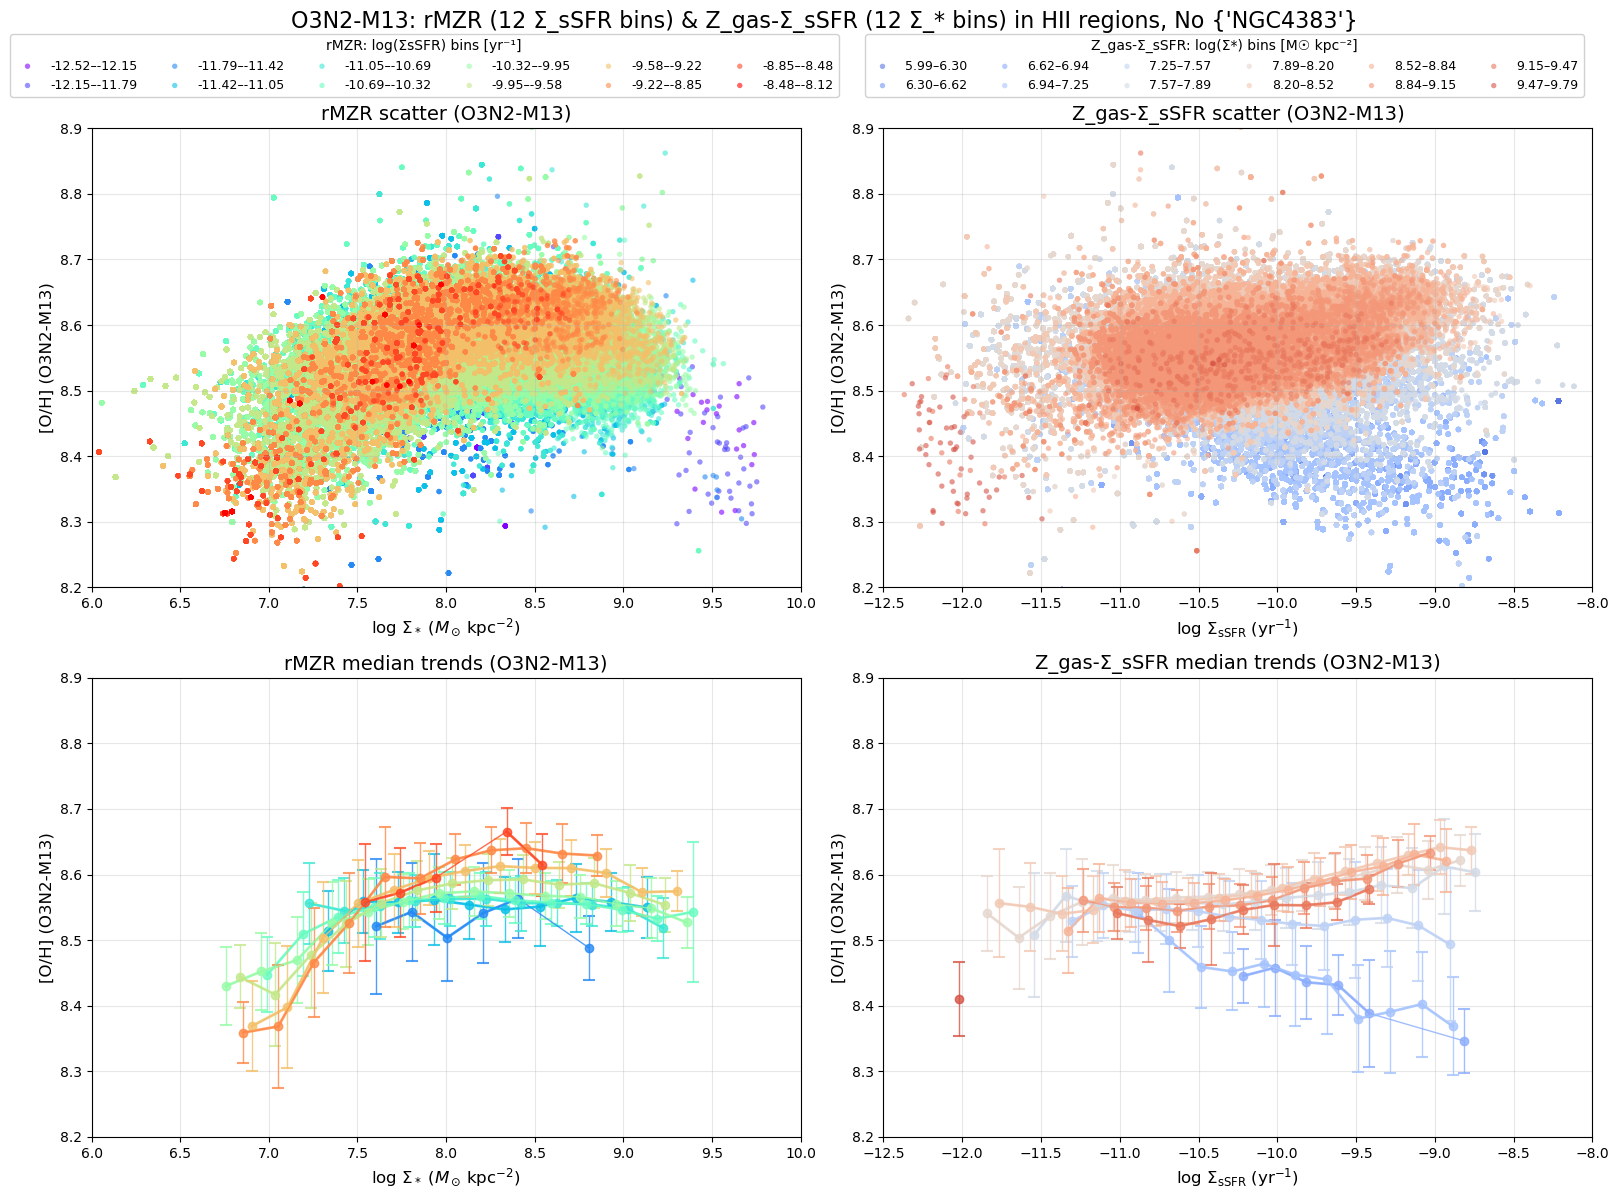


COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (12 Σ_sSFR bins)
  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)
  Bottom-left: rMZR median trends (12 Σ_sSFR bins)
  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
# Using O3N2-M13 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_SFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_SFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_m13(gal):
    """Load O3N2-M13 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_m13_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_m13_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)

# Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
all_logSigmasSFR_HII = all_logSigmaSFR_HII - all_logSigmaM_HII

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_sSFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width sSFR bins for rMZR")
print("="*80)

# Get sSFR range
ssfr_min = np.min(all_logSigmasSFR_HII)
ssfr_max = np.max(all_logSigmasSFR_HII)
ssfr_range = ssfr_max - ssfr_min

print(f"\nΣ_sSFR range:")
print(f"  Min: {ssfr_min:.3f}")
print(f"  Max: {ssfr_max:.3f}")
print(f"  Range: {ssfr_range:.3f}")

# Define 12 bins with equal width
n_bins = 12
bin_width = ssfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
ssfr_bin_edges = np.linspace(ssfr_min, ssfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{ssfr_bin_edges[i]:.2f}–{ssfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width sSFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_ssfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_SFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_SFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_SFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.2, 8.9)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-M13 data
oh_data_HII = all_oh_o3n2_m13_HII
calib_name_HII = 'O3N2-M13'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 12 Σ_sSFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_sSFR bins) ---")

legend_handles_ssfr = []
legend_labels_ssfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII <= ssfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_ssfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_ssfr.append(scatter_hii)
        legend_labels_ssfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_ssfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_ssfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_sSFR scatter (in 12 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_sSFR (12 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_sSFR, y=[O/H])
        x_bin_HII = all_logSigmasSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_sSFR)
        ssfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(ssfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(ssfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([ssfr_centers_HII[j], ssfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_sSFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_sSFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-12.5, -8.0)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_sSFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_sSFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-12.5, -8.0)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_sSFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (12 Σ_sSFR bins) & Z_gas-Σ_sSFR (12 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_ssfr, legend_labels_ssfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣsSFR) bins [yr⁻¹]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_sSFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_O3N2M13_2x2_12bins.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_O3N2M13_2x2_12bins.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (O3N2-M13 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (12 Σ_sSFR bins)")
print("  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)")
print("  Bottom-left: rMZR median trends (12 Σ_sSFR bins)")
print("  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-C20 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=7067 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5715 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4298: HII=156350 pixels
  NGC4330: HII=42998 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4396: HII=81745 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4457: HII=6310 pixels
  NGC4501: HII=261083 pixels
  NGC4522: HII=39665 pixels
  NGC4522: HII=39665 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10181 pixels

Total combined pixels (HII): 781881

STEP 2: Defining 12 equal-width sSFR bins for rMZR

Σ_sSFR range:
  Min: -12.520
  Max: -8.117
  Range: 4.404

Bin width: 0.367

12 equal-width sSFR b

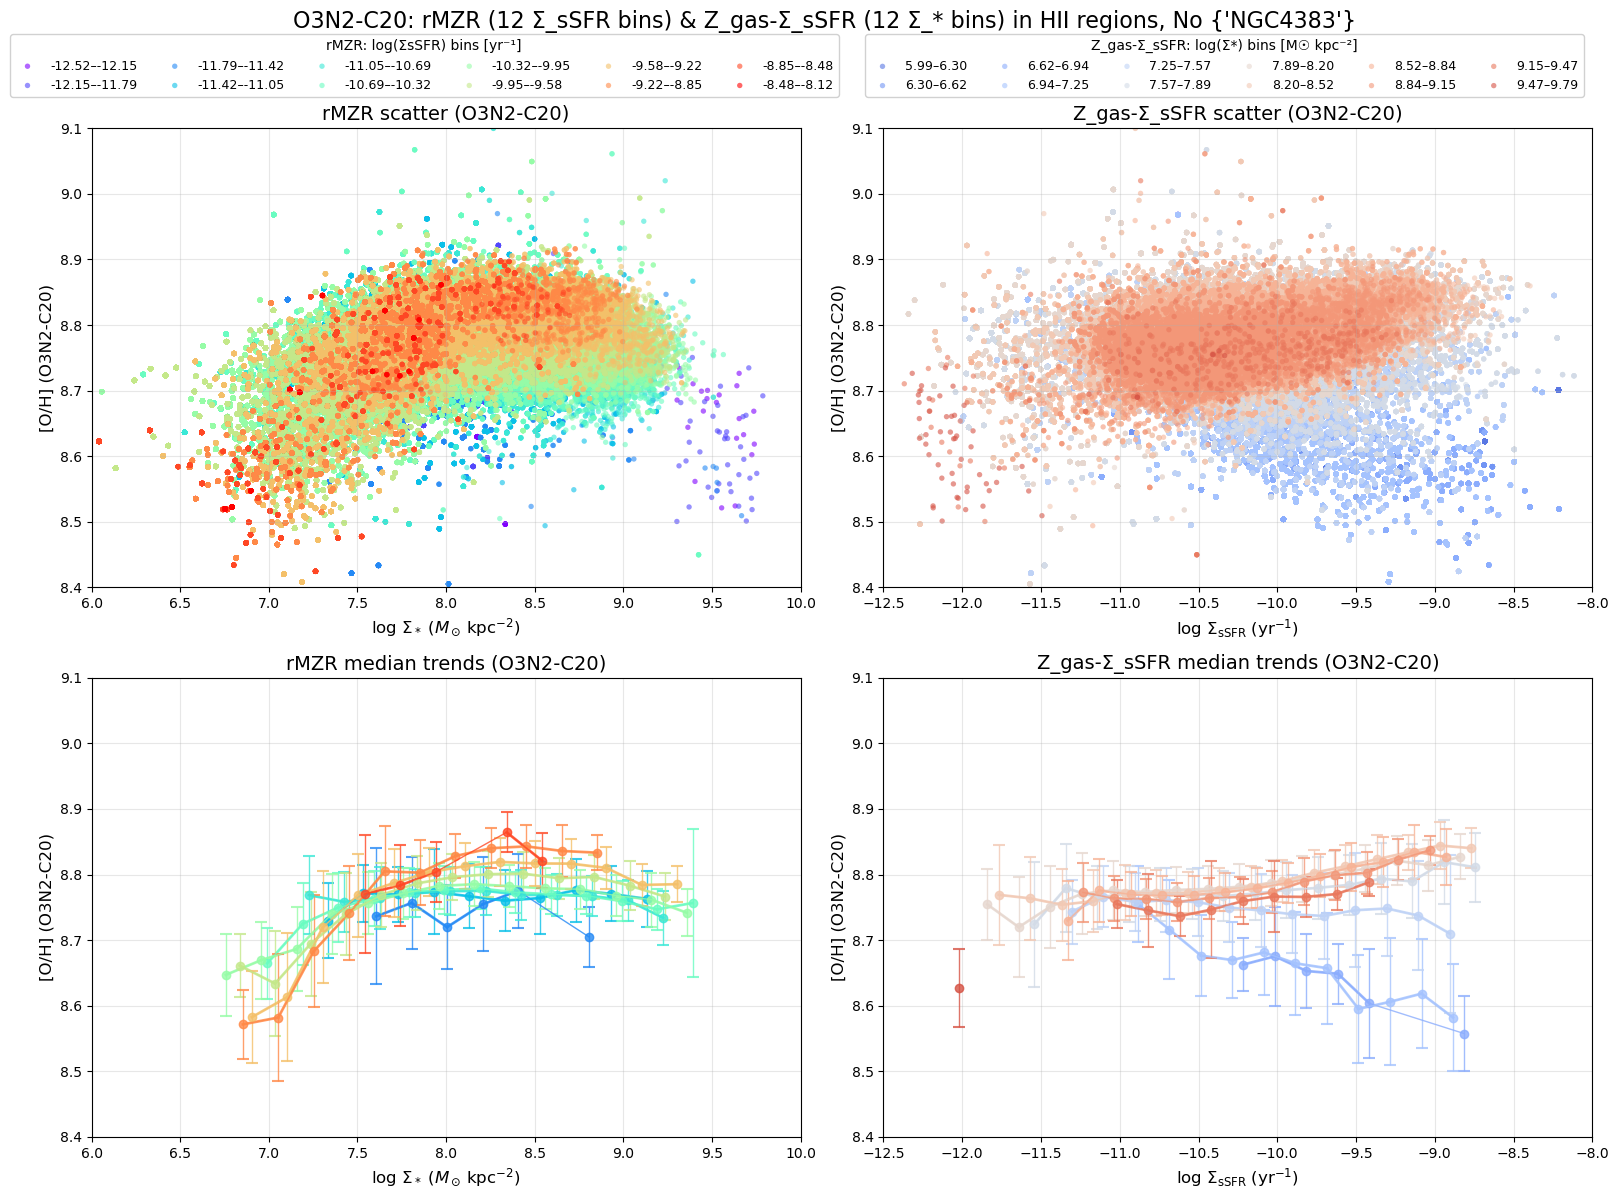


COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (O3N2-C20 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (12 Σ_sSFR bins)
  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)
  Bottom-left: rMZR median trends (12 Σ_sSFR bins)
  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)
  Shared y-range: 8.4 to 9.1


In [2]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_sSFR relation - HII regions only
# Using O3N2-C20 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_sSFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_sSFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_o3n2_c20(gal):
    """Load O3N2-C20 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
    return (sigM, sigSFR_HII, oh_o3n2_c20_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_o3n2_c20_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-C20 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_o3n2_c20_HII) = load_maps_o3n2_c20(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_o3n2_c20_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

# Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
all_logSigmasSFR_HII = all_logSigmaSFR_HII - all_logSigmaM_HII

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_sSFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width sSFR bins for rMZR")
print("="*80)

# Get sSFR range
ssfr_min = np.min(all_logSigmasSFR_HII)
ssfr_max = np.max(all_logSigmasSFR_HII)
ssfr_range = ssfr_max - ssfr_min

print(f"\nΣ_sSFR range:")
print(f"  Min: {ssfr_min:.3f}")
print(f"  Max: {ssfr_max:.3f}")
print(f"  Range: {ssfr_range:.3f}")

# Define 12 bins with equal width
n_bins = 12
bin_width = ssfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
ssfr_bin_edges = np.linspace(ssfr_min, ssfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{ssfr_bin_edges[i]:.2f}–{ssfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width sSFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_ssfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_sSFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_sSFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_sSFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (O3N2-C20 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.4, 9.1)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use O3N2-C20 data
oh_data_HII = all_oh_o3n2_c20_HII
calib_name_HII = 'O3N2-C20'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 12 Σ_sSFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_sSFR bins) ---")

legend_handles_ssfr = []
legend_labels_ssfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII <= ssfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_ssfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_ssfr.append(scatter_hii)
        legend_labels_ssfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_ssfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_ssfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_sSFR scatter (in 12 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_sSFR (12 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_sSFR, y=[O/H])
        x_bin_HII = all_logSigmasSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_sSFR)
        ssfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(ssfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(ssfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([ssfr_centers_HII[j], ssfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_sSFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_sSFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-12.5, -8.0)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_sSFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_sSFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-12.5, -8.0)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_sSFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (12 Σ_sSFR bins) & Z_gas-Σ_sSFR (12 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_ssfr, legend_labels_ssfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣsSFR) bins [yr⁻¹]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_sSFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_O3N2C20_2x2_12bins.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_O3N2C20_2x2_12bins.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (O3N2-C20 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (12 Σ_sSFR bins)")
print("  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)")
print("  Bottom-left: rMZR median trends (12 Σ_sSFR bins)")
print("  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (D16 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=6949 pixels
  NGC4064: HII=6949 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=4301 pixels
  NGC4298: HII=156350 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=4301 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42748 pixels
  NGC4383: excluded from analysis
  NGC4330: HII=42748 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81742 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6304 pixels
  NGC4501: HII=261001 pixels
  NGC4396: HII=81742 pixels
  NGC4419: HII=7354 pixels
  NGC4457: HII=6304 pixels
  NGC4501: HII=261001 pixels
  NGC4522: HII=39581 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10129 pixels

Total combined pixels (HII): 779862

STEP 2: Defining 12 equal-width sSFR bins for rMZR

Σ_sSFR range:
  Min: -12.520
  Max: -8.117
  Range: 4.404

Bin width: 0.367

12 equal-width sSFR bins:
  Bin 1: -12.52–-12.15
  Bin 2: -12.15–-11.79
  Bin 3: 

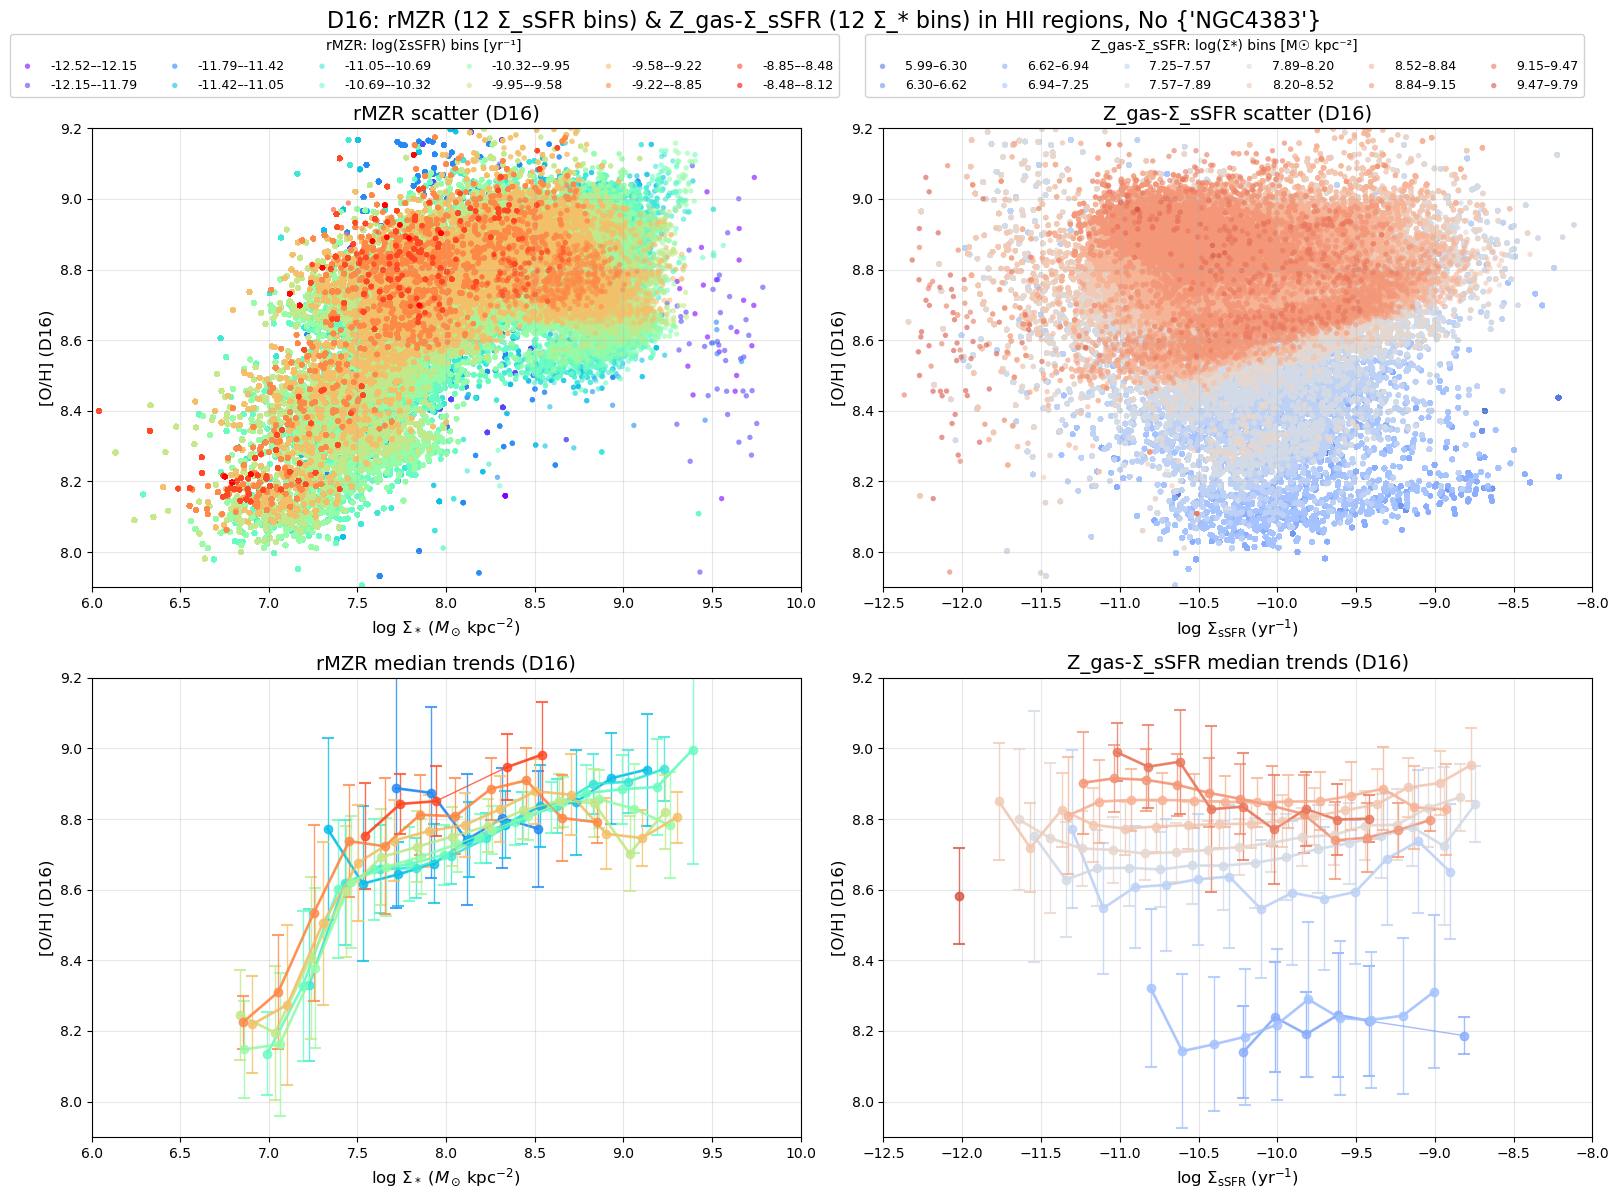


COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (D16 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (12 Σ_sSFR bins)
  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)
  Bottom-left: rMZR median trends (12 Σ_sSFR bins)
  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)
  Shared y-range: 7.9 to 9.2


In [3]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_sSFR relation - HII regions only
# Using D16 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_sSFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_sSFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_d16(gal):
    """Load D16 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
    return (sigM, sigSFR_HII, oh_d16_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (D16 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII) = load_maps_d16(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)

# Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
all_logSigmasSFR_HII = all_logSigmaSFR_HII - all_logSigmaM_HII

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_sSFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width sSFR bins for rMZR")
print("="*80)

# Get sSFR range
ssfr_min = np.min(all_logSigmasSFR_HII)
ssfr_max = np.max(all_logSigmasSFR_HII)
ssfr_range = ssfr_max - ssfr_min

print(f"\nΣ_sSFR range:")
print(f"  Min: {ssfr_min:.3f}")
print(f"  Max: {ssfr_max:.3f}")
print(f"  Range: {ssfr_range:.3f}")

# Define 12 bins with equal width
n_bins = 12
bin_width = ssfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
ssfr_bin_edges = np.linspace(ssfr_min, ssfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{ssfr_bin_edges[i]:.2f}–{ssfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width sSFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_ssfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_sSFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_sSFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_sSFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (D16 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (7.9, 9.2)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use D16 data
oh_data_HII = all_oh_d16_HII
calib_name_HII = 'D16'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 12 Σ_sSFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_sSFR bins) ---")

legend_handles_ssfr = []
legend_labels_ssfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII <= ssfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_ssfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_ssfr.append(scatter_hii)
        legend_labels_ssfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_ssfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_ssfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_sSFR scatter (in 12 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_sSFR (12 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_sSFR, y=[O/H])
        x_bin_HII = all_logSigmasSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_sSFR)
        ssfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(ssfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(ssfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([ssfr_centers_HII[j], ssfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_sSFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_sSFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-12.5, -8.0)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_sSFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_sSFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-12.5, -8.0)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_sSFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (12 Σ_sSFR bins) & Z_gas-Σ_sSFR (12 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_ssfr, legend_labels_ssfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣsSFR) bins [yr⁻¹]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_sSFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_D16_2x2_12bins.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_D16_2x2_12bins.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (D16 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (12 Σ_sSFR bins)")
print("  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)")
print("  Bottom-left: rMZR median trends (12 Σ_sSFR bins)")
print("  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


STEP 1: Collecting data from all galaxies for HII regions (PG16 only)...
  IC3392: HII=14884 pixels
  NGC4064: HII=6938 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5084 pixels
  IC3392: HII=14884 pixels
  NGC4064: HII=6938 pixels
  NGC4192: HII=145944 pixels
  NGC4293: HII=5084 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42604 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81730 pixels
  NGC4419: HII=6886 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42604 pixels
  NGC4383: excluded from analysis
  NGC4396: HII=81730 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6006 pixels
  NGC4501: HII=260902 pixels
  NGC4522: HII=39354 pixels
  NGC4457: HII=6006 pixels
  NGC4501: HII=260902 pixels
  NGC4522: HII=39354 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10065 pixels

Total combined pixels (HII): 779332

STEP 2: Defining 12 equal-width sSFR bins for rMZR

Σ_sSFR range:
  Min: -12.520
  Max: -8.117
  Range: 4.404

Bin width: 0.367

12 equal-width sSFR bins:

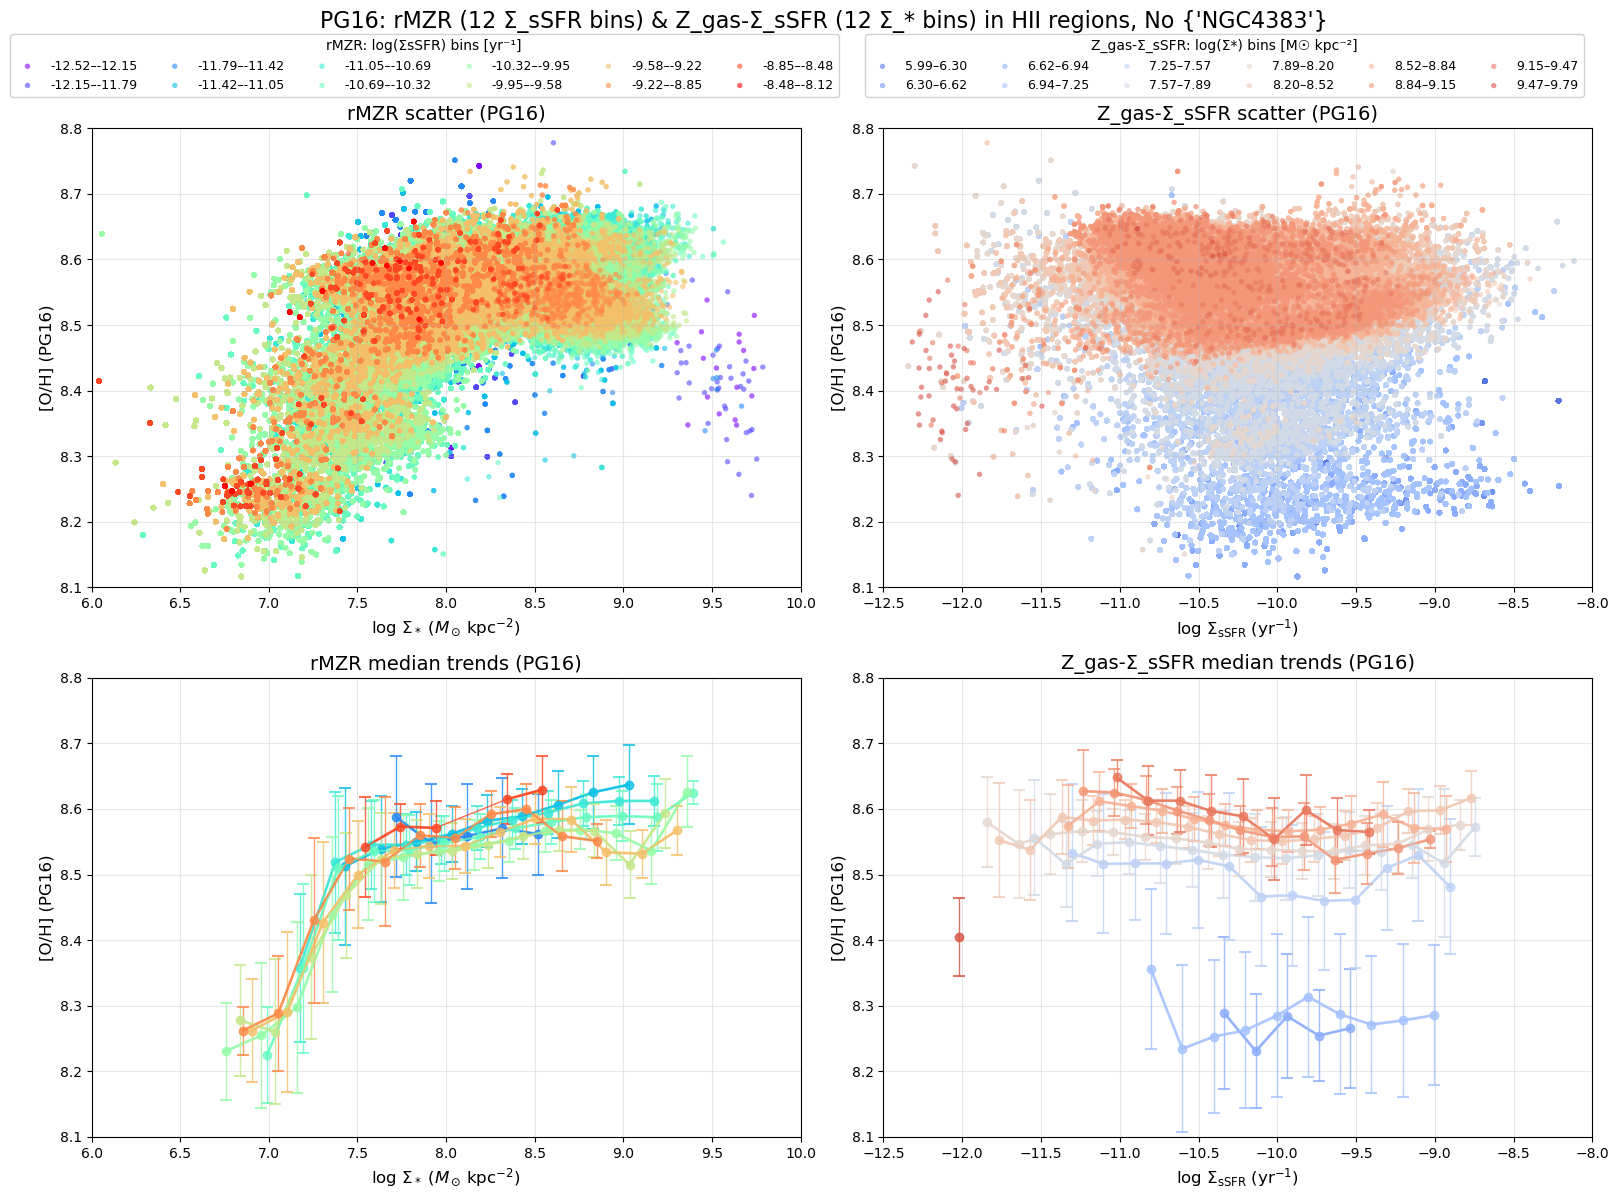


COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (PG16 only)
Successfully created 2x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (12 Σ_sSFR bins)
  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)
  Bottom-left: rMZR median trends (12 Σ_sSFR bins)
  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)
  Shared y-range: 8.1 to 8.8


In [4]:
# ------------------------------------------------------------------
# Combined Analysis: rMZR and Z_gas-Σ_sSFR relation - HII regions only
# Using PG16 indicator only
# 2x2 subplot layout:
#   Top-left: rMZR scatter
#   Top-right: Z_gas-Σ_sSFR scatter
#   Bottom-left: rMZR median trends
#   Bottom-right: Z_gas-Σ_sSFR median trends
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_pg16(gal):
    """Load PG16 metallicity calibration for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
    return (sigM, sigSFR_HII, oh_pg16_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in bins - only keep bins with >= 20 unique datapoints"""
    # Define bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
        # Select data in this bin
        in_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_pg16_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions (PG16 only)...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_pg16_HII) = load_maps_pg16(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_pg16_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)

# Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
all_logSigmasSFR_HII = all_logSigmaSFR_HII - all_logSigmaM_HII

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 12 equal-width Σ_sSFR bins for rMZR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 12 equal-width sSFR bins for rMZR")
print("="*80)

# Get sSFR range
ssfr_min = np.min(all_logSigmasSFR_HII)
ssfr_max = np.max(all_logSigmasSFR_HII)
ssfr_range = ssfr_max - ssfr_min

print(f"\nΣ_sSFR range:")
print(f"  Min: {ssfr_min:.3f}")
print(f"  Max: {ssfr_max:.3f}")
print(f"  Range: {ssfr_range:.3f}")

# Define 12 bins with equal width
n_bins = 12
bin_width = ssfr_range / n_bins

print(f"\nBin width: {bin_width:.3f}")

# Create bin edges
ssfr_bin_edges = np.linspace(ssfr_min, ssfr_max, n_bins + 1)

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{ssfr_bin_edges[i]:.2f}–{ssfr_bin_edges[i+1]:.2f}')

print(f"\n12 equal-width sSFR bins:")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Colors for different bins using rainbow colormap
colors_ssfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

# ==============================================================================
# STEP 3: Define 12 Σ_* bins for Z_gas-Σ_sSFR analysis
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Defining 12 Σ_* bins with equal width for Z_gas-Σ_sSFR")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 12 Σ_* bins with equal width across the actual data range
n_bins_sigmaM = 12
bin_width_sigmaM = sigmaM_range / n_bins_sigmaM
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_sigmaM + 1)

print(f"  Bin width: {bin_width_sigmaM:.3f} dex")

# Create bin labels for Σ_* bins
bin_labels_sigmaM = []
for i in range(n_bins_sigmaM):
    bin_labels_sigmaM.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n12 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels_sigmaM):
    print(f"  Bin {i+1}: {label}")

# Colors for 12 Σ_* bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

# ==============================================================================
# STEP 4: Create combined 2x2 figure (rMZR & Z_gas-Σ_sSFR)
# ==============================================================================
print("\n" + "="*80)
print("STEP 4: Creating combined 2x2 plot (PG16 only)")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.1, 8.8)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 2 rows x 2 columns 
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Use PG16 data
oh_data_HII = all_oh_pg16_HII
calib_name_HII = 'PG16'

print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")

# Assign axes
ax_rMZR_scatter = axes[0, 0]
ax_Zgas_scatter = axes[0, 1]
ax_rMZR_median = axes[1, 0]
ax_Zgas_median = axes[1, 1]

# =============================================================================
# TOP ROW LEFT: rMZR scatter (in 12 Σ_sSFR bins)
# =============================================================================
print(f"\n--- Processing rMZR (12 Σ_sSFR bins) ---")

legend_handles_ssfr = []
legend_labels_ssfr = []

valid_bins_rMZR = 0
for i in range(n_bins):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    elif i == n_bins - 1:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII <= ssfr_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmasSFR_HII >= ssfr_bin_edges[i]) & (all_logSigmasSFR_HII < ssfr_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_*, y=[O/H])
        x_bin_HII = all_logSigmaM_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_rMZR_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_ssfr[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_ssfr.append(scatter_hii)
        legend_labels_ssfr.append(bin_labels[i])
        
        # Median trends
        mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(mass_centers_HII) > 0:
            ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_ssfr[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_ssfr[i], linewidth=2, alpha=0.8)
            valid_bins_rMZR += 1

# Format rMZR scatter plot
ax_rMZR_scatter.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_scatter.set_title(f'rMZR scatter ({calib_name_HII})', fontsize=14)
ax_rMZR_scatter.grid(True, alpha=0.3)
ax_rMZR_scatter.set_xlim(6, 10)
ax_rMZR_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW LEFT: rMZR median trends
# =============================================================================
ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_rMZR_median.set_title(f'rMZR median trends ({calib_name_HII})', fontsize=14)
ax_rMZR_median.grid(True, alpha=0.3)
ax_rMZR_median.set_xlim(6, 10)
ax_rMZR_median.set_ylim(common_ylim)

print(f"  rMZR valid bins: {valid_bins_rMZR}")

# =============================================================================
# TOP ROW RIGHT: Z_gas-Σ_sSFR scatter (in 12 Σ_* bins)
# =============================================================================
print(f"\n--- Processing Z_gas-Σ_sSFR (12 Σ_* bins) ---")

legend_handles_sigmaM = []
legend_labels_sigmaM_display = []

valid_bins_Zgas = 0
for i in range(n_bins_sigmaM):
    # HII regions processing
    if i == 0:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins_sigmaM - 1:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    
    n_pixels_HII = np.sum(in_bin_HII)
    
    if n_pixels_HII >= 10:
        # Get data for this bin (x=Σ_sSFR, y=[O/H])
        x_bin_HII = all_logSigmasSFR_HII[in_bin_HII]
        y_bin_HII = oh_data_HII[in_bin_HII]
        
        # Scatter plot
        scatter_hii = ax_Zgas_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors_sigmaM[i]], s=15, alpha=0.6, 
                             edgecolors='none', rasterized=True)
        
        legend_handles_sigmaM.append(scatter_hii)
        legend_labels_sigmaM_display.append(bin_labels_sigmaM[i])
        
        # Median trends (now bin by Σ_sSFR)
        ssfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
            x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
        
        if len(ssfr_centers_HII) > 0:
            ax_Zgas_median.errorbar(ssfr_centers_HII, medians_HII, yerr=stds_HII, 
                       color=colors_sigmaM[i], marker='o', markersize=6, 
                       linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
            
            # Add lines between adjacent bins
            for j in range(len(valid_bin_indices_HII) - 1):
                current_bin_idx = valid_bin_indices_HII[j]
                next_bin_idx = valid_bin_indices_HII[j + 1]
                if next_bin_idx - current_bin_idx == 1:
                    ax_Zgas_median.plot([ssfr_centers_HII[j], ssfr_centers_HII[j + 1]], 
                           [medians_HII[j], medians_HII[j + 1]], 
                           color=colors_sigmaM[i], linewidth=2, alpha=0.8)
            valid_bins_Zgas += 1

# Format Z_gas-Σ_sSFR scatter plot
ax_Zgas_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_scatter.set_title(f'Z_gas-Σ_sSFR scatter ({calib_name_HII})', fontsize=14)
ax_Zgas_scatter.grid(True, alpha=0.3)
ax_Zgas_scatter.set_xlim(-12.5, -8.0)
ax_Zgas_scatter.set_ylim(common_ylim)

# =============================================================================
# BOTTOM ROW RIGHT: Z_gas-Σ_sSFR median trends
# =============================================================================
ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{sSFR} \; (\mathrm{yr}^{-1})$', fontsize=12)
ax_Zgas_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
ax_Zgas_median.set_title(f'Z_gas-Σ_sSFR median trends ({calib_name_HII})', fontsize=14)
ax_Zgas_median.grid(True, alpha=0.3)
ax_Zgas_median.set_xlim(-12.5, -8.0)
ax_Zgas_median.set_ylim(common_ylim)

print(f"  Z_gas-Σ_sSFR valid bins: {valid_bins_Zgas}")

# Add overall title
fig.suptitle(f'{calib_name_HII}: rMZR (12 Σ_sSFR bins) & Z_gas-Σ_sSFR (12 Σ_* bins) in HII regions, No {excluded_galaxies}', 
             fontsize=16, y=0.995)

# Add legends - one for each row (positions unchanged)
legend1 = fig.legend(legend_handles_ssfr, legend_labels_ssfr, loc='upper center', 
                    bbox_to_anchor=(0.25, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='rMZR: log(ΣsSFR) bins [yr⁻¹]', title_fontsize=10)
legend2 = fig.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', 
                    bbox_to_anchor=(0.75, 0.98), ncol=6, fontsize=9, framealpha=0.9,
                    title='Z_gas-Σ_sSFR: log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_PG16_2x2_12bins.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_rMZR_Zgas_SigmasSFR_PG16_2x2_12bins.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: Combined rMZR and Z_gas-Σ_sSFR analysis (PG16 only)")
print("="*80)
print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print("\nPanel summary:")
print("  Top-left: rMZR scatter (12 Σ_sSFR bins)")
print("  Top-right: Z_gas-Σ_sSFR scatter (12 Σ_* bins)")
print("  Bottom-left: rMZR median trends (12 Σ_sSFR bins)")
print("  Bottom-right: Z_gas-Σ_sSFR median trends (12 Σ_* bins)")
print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")


## 20251022 How about the correlation between $\Delta\rm{[O/H]}$ and $\Delta\log(\mathrm{sSFR})$?

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_4270/4243841310.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(galaxies))


Creating 2x2 combined plots for 13 galaxies...
Included galaxies: ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']

Processing indicators...

D16:
D16: r = 0.230, p = 0.000e+00, N = 779,862

PG16:
D16: r = 0.230, p = 0.000e+00, N = 779,862

PG16:
PG16: r = -0.026, p = 1.149e-117, N = 779,332

O3N2-M13:
PG16: r = -0.026, p = 1.149e-117, N = 779,332

O3N2-M13:
O3N2-M13: r = 0.070, p = 0.000e+00, N = 781,881

O3N2-C20:
O3N2-M13: r = 0.070, p = 0.000e+00, N = 781,881

O3N2-C20:
O3N2-C20: r = 0.054, p = 0.000e+00, N = 781,881
O3N2-C20: r = 0.054, p = 0.000e+00, N = 781,881


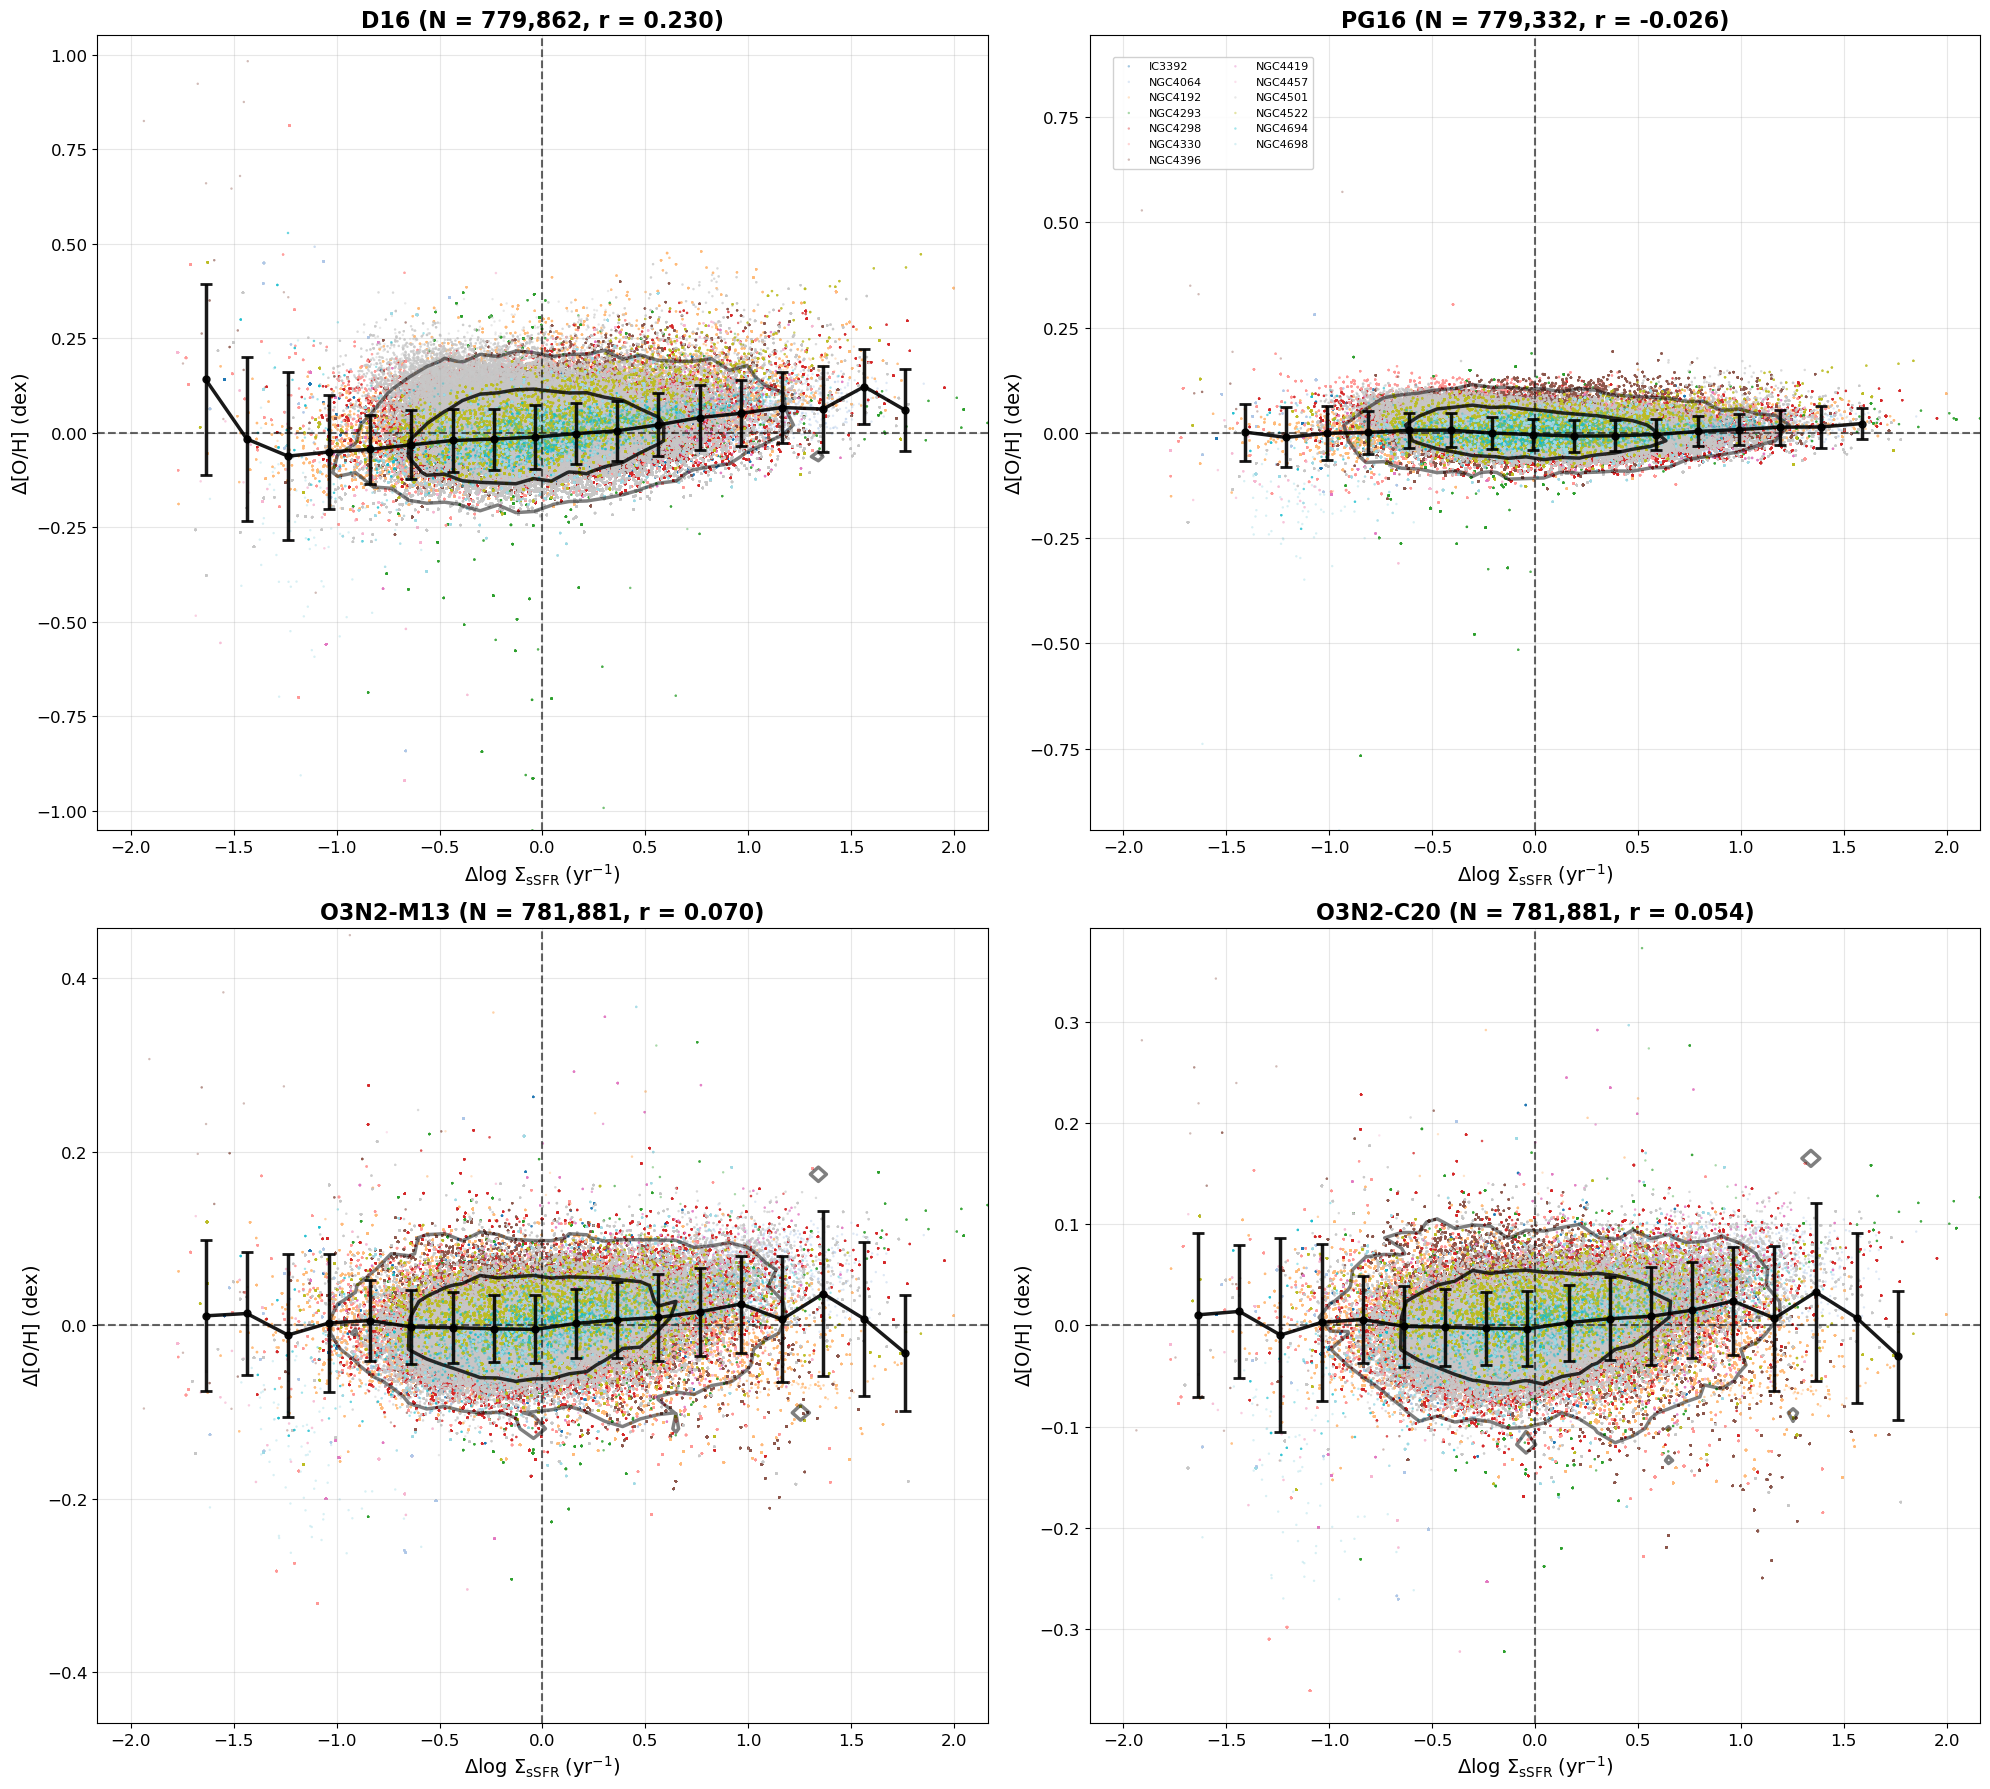


2x2 combined plot complete!


In [5]:
# ------------------------------------------------------------------
# Combined plot: 2x2 subplots for different metallicity indicators
# D16 (top left), PG16 (top right), O3N2-M13 (bottom left), O3N2-C20 (bottom right)
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.cm as cm

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

# Create color map - preserve color position for all galaxies including excluded ones
cmap = cm.get_cmap('tab20', len(galaxies))
galaxy_colors = {gal: cmap(i) for i, gal in enumerate(galaxies)}

print(f"Creating 2x2 combined plots for {len(included_galaxies)} galaxies...")
print(f"Included galaxies: {included_galaxies}")

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def load_maps(gal, indicator='O3N2-M13'):
    """Load maps for a specific metallicity indicator."""
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        
        # Select metallicity indicator
        if indicator == 'O3N2-M13':
            oh_map = h_gas['O_H_O3N2_M13_HII'].data
        elif indicator == 'O3N2-C20':
            oh_map = h_gas['O_H_O3N2_C20_HII'].data
        elif indicator == 'D16':
            oh_map = h_gas['O_H_D16_HII'].data
        elif indicator == 'PG16':
            oh_map = h_gas['O_H_PG16_HII'].data
        else:
            raise ValueError(f"Unknown indicator: {indicator}")
        
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    
    return sigM, sigSFR, oh_map, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

def collect_data_for_indicator(indicator_name):
    """Collect offset data for all galaxies for a given metallicity indicator."""
    all_delta_ssfr = []
    all_delta_oh = []
    all_colors = []
    galaxy_data = {}
    
    for gal in included_galaxies:
        try:
            sigM, sigSFR, oh_map, wcs_full, gas_header = load_maps(gal, indicator_name)

            # Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
            sigsSFR = sigSFR - sigM

            # Valid pixels across maps
            valid_ssfr = np.isfinite(sigsSFR)
            valid_oh = np.isfinite(oh_map)
            valid_all = valid_ssfr & valid_oh

            # Calculate mean values for offset calculation
            ssfr_mean = np.nanmean(sigsSFR[valid_ssfr])
            oh_mean = np.nanmean(oh_map[valid_oh])
            
            # Create offset maps (difference from mean)
            ssfr_offset = sigsSFR - ssfr_mean
            oh_offset = oh_map - oh_mean

            # Extract valid data points
            delta_ssfr = ssfr_offset[valid_all]
            delta_oh = oh_offset[valid_all]
            
            # Store for this galaxy
            galaxy_data[gal] = {
                'delta_ssfr': delta_ssfr,
                'delta_oh': delta_oh,
                'color': galaxy_colors[gal]
            }
            
            # Add to combined arrays
            all_delta_ssfr.extend(delta_ssfr)
            all_delta_oh.extend(delta_oh)
            all_colors.extend([galaxy_colors[gal]] * len(delta_ssfr))
            
        except Exception as e:
            print(f"  Error loading {gal} for {indicator_name}: {e}")
    
    # Convert to numpy arrays
    all_delta_ssfr = np.array(all_delta_ssfr)
    all_delta_oh = np.array(all_delta_oh)
    all_colors = np.array(all_colors)
    
    return all_delta_ssfr, all_delta_oh, galaxy_data

def plot_indicator_panel(ax, all_delta_ssfr, all_delta_oh, galaxy_data, indicator_name, show_legend=False):
    """Plot a single panel for one metallicity indicator."""
    
    # Calculate symmetric axis limits
    max_abs_ssfr = np.nanmax(np.abs(all_delta_ssfr))
    max_abs_oh = np.nanmax(np.abs(all_delta_oh))

    # Plot scatter points for each galaxy with its color
    for gal in included_galaxies:
        if gal in galaxy_data:
            data = galaxy_data[gal]
            ax.scatter(data['delta_ssfr'], data['delta_oh'], 
                      c=[data['color']], s=3, alpha=0.4, edgecolors='none', 
                      rasterized=True, label=gal if show_legend else None)

    # Create 2D histogram for COMBINED contours (in black)
    H, xedges, yedges = np.histogram2d(all_delta_ssfr, all_delta_oh, bins=50,
                                       range=[[-max_abs_ssfr, max_abs_ssfr],
                                              [-max_abs_oh, max_abs_oh]])
    H = H.T

    # Calculate cumulative distribution for contour levels
    H_sorted = np.sort(H.flatten())[::-1]
    H_cumsum = np.cumsum(H_sorted)
    H_cumsum = H_cumsum / H_cumsum[-1]

    # Find levels for 68% and 95%
    level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
    level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]

    # Plot COMBINED contours in black
    X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
    if level_95 < level_68:
        levels_to_plot = [level_95, level_68]
        alphas = [0.5, 0.8]
    elif level_95 > level_68:
        levels_to_plot = [level_68, level_95]
        alphas = [0.8, 0.5]
    else:
        levels_to_plot = [level_68]
        alphas = [0.8]

    if len(levels_to_plot) > 0:
        for level, alpha in zip(levels_to_plot, alphas):
            ax.contour(X, Y, H, levels=[level], colors=['black'],
                      linewidths=[2.5], alpha=alpha)

    # Calculate COMBINED median trend (in black)
    bin_centers, medians, stds, counts = calculate_binned_stats(
        all_delta_ssfr, all_delta_oh, bin_width=0.2, min_pixels=20)

    if len(bin_centers) > 0:
        ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                   color='black', markersize=5, linewidth=2.5, capsize=4, 
                   capthick=2, alpha=0.9, zorder=10)

    # Calculate Pearson correlation for combined data
    n_unique = len(np.unique(np.column_stack([all_delta_ssfr, all_delta_oh]), axis=0))
    if n_unique >= 20:
        pearson_r, pearson_p = pearsonr(all_delta_ssfr, all_delta_oh)
        print(f"{indicator_name}: r = {pearson_r:.3f}, p = {pearson_p:.3e}, N = {len(all_delta_ssfr):,}")
    else:
        pearson_r = None
        print(f"{indicator_name}: Insufficient unique data (N_unique = {n_unique})")

    # Set symmetric limits
    ax.set_xlim(-max_abs_ssfr, max_abs_ssfr)
    ax.set_ylim(-max_abs_oh, max_abs_oh)

    # Add grid and center lines
    ax.axhline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.6)
    ax.grid(True, alpha=0.3)

    # Labels
    ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{sSFR}} \; (\mathrm{yr}^{-1})$', fontsize=14)
    ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=14)

    # Title
    if pearson_r is not None:
        title = f'{indicator_name} (N = {len(all_delta_ssfr):,}, r = {pearson_r:.3f})'
    else:
        title = f'{indicator_name} (N = {len(all_delta_ssfr):,})'
    ax.set_title(title, fontsize=16, fontweight='bold')

    ax.tick_params(labelsize=12)
    
    return pearson_r

# ------------------------------------------------------------------
# Create 2x2 subplot layout
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# Define indicators and their positions
# Top row: D16 (left), PG16 (right)
# Bottom row: O3N2-M13 (left), O3N2-C20 (right)
indicators = {
    'D16': (0, 0),      # Top left
    'PG16': (0, 1),     # Top right
    'O3N2-M13': (1, 0), # Bottom left
    'O3N2-C20': (1, 1)  # Bottom right
}

print("\nProcessing indicators...")
for indicator_name, (row, col) in indicators.items():
    print(f"\n{indicator_name}:")
    
    # Collect data for this indicator
    all_delta_ssfr, all_delta_oh, galaxy_data = collect_data_for_indicator(indicator_name)
    
    # Plot in the corresponding subplot
    # Show legend only in top-right panel (PG16)
    show_legend = (indicator_name == 'PG16')
    plot_indicator_panel(axes[row, col], all_delta_ssfr, all_delta_oh, 
                        galaxy_data, indicator_name, show_legend=show_legend)
    
    # Add legend to PG16 panel
    if show_legend:
        axes[row, col].legend(loc='upper left', fontsize=8, ncol=2, framealpha=0.9, 
                             bbox_to_anchor=(0.02, 0.98))

plt.tight_layout()
# plt.savefig('Combined_2x2_Delta_OH_vs_Delta_SigmasSFR_4indicators.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_2x2_Delta_OH_vs_Delta_SigmasSFR_4indicators.pdf', bbox_inches='tight')
plt.show()

print("\n2x2 combined plot complete!")


Creating mass-binned offset plots for 13 galaxies...
Included galaxies: ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']
Loading IC3392...
  IC3392: 14,884 pixels
Loading NGC4064...
  NGC4064: 7,067 pixels
Loading NGC4192...
  NGC4064: 7,067 pixels
Loading NGC4192...
  NGC4192: 145,944 pixels
Loading NGC4293...
  NGC4293: 5,715 pixels
Loading NGC4298...
  NGC4192: 145,944 pixels
Loading NGC4293...
  NGC4293: 5,715 pixels
Loading NGC4298...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4330: 42,998 pixels
Loading NGC4396...
  NGC4396: 81,745 pixels
Loading NGC4419...
  NGC4419: 7,354 pixels
Loading NGC4457...
  NGC4457: 6,310 pixels
Loading NGC4501...
  NGC4330: 42,998 pixels
Loading NGC4396...
  NGC4396: 81,745 pixels
Loading NGC4419...
  NGC4419: 7,354 pixels
Loading NGC4457...
  NGC4457: 6,310 pixels
Loading NGC4501...
  NGC4501: 261,083 pixel

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_4270/3035331274.py:133: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mass = cm.get_cmap('coolwarm', n_bins_mass)



Mass bin range: 5.99 to 9.79
Bin width: 0.317

Mass bin 1: [5.99, 6.30), N = 995
  Insufficient unique data (N_unique = 6)

Mass bin 2: [6.30, 6.62), N = 3,900
  r = -0.561, p = 6.818e-322

Mass bin 3: [6.62, 6.94), N = 26,774
  r = -0.370, p = 0.000e+00

Mass bin 4: [6.94, 7.25), N = 66,623
  r = -0.373, p = 0.000e+00

Mass bin 5: [7.25, 7.57), N = 107,092
  r = -0.135, p = 0.000e+00

Mass bin 6: [7.57, 7.89), N = 186,095
  r = 0.134, p = 0.000e+00

Mass bin 7: [7.89, 8.20), N = 193,470
  r = 0.231, p = 0.000e+00

Mass bin 8: [8.20, 8.52), N = 115,173
  r = 0.332, p = 0.000e+00

Mass bin 9: [8.52, 8.84), N = 67,406
  r = 0.134, p = 0.000e+00

Mass bin 7: [7.89, 8.20), N = 193,470
  r = 0.231, p = 0.000e+00

Mass bin 8: [8.20, 8.52), N = 115,173
  r = 0.332, p = 0.000e+00

Mass bin 9: [8.52, 8.84), N = 67,406
  r = 0.335, p = 0.000e+00

Mass bin 10: [8.84, 9.15), N = 13,797
  r = 0.444, p = 0.000e+00

Mass bin 11: [9.15, 9.47), N = 502
  r = 0.406, p = 2.321e-21

Mass bin 12: [9.47, 9

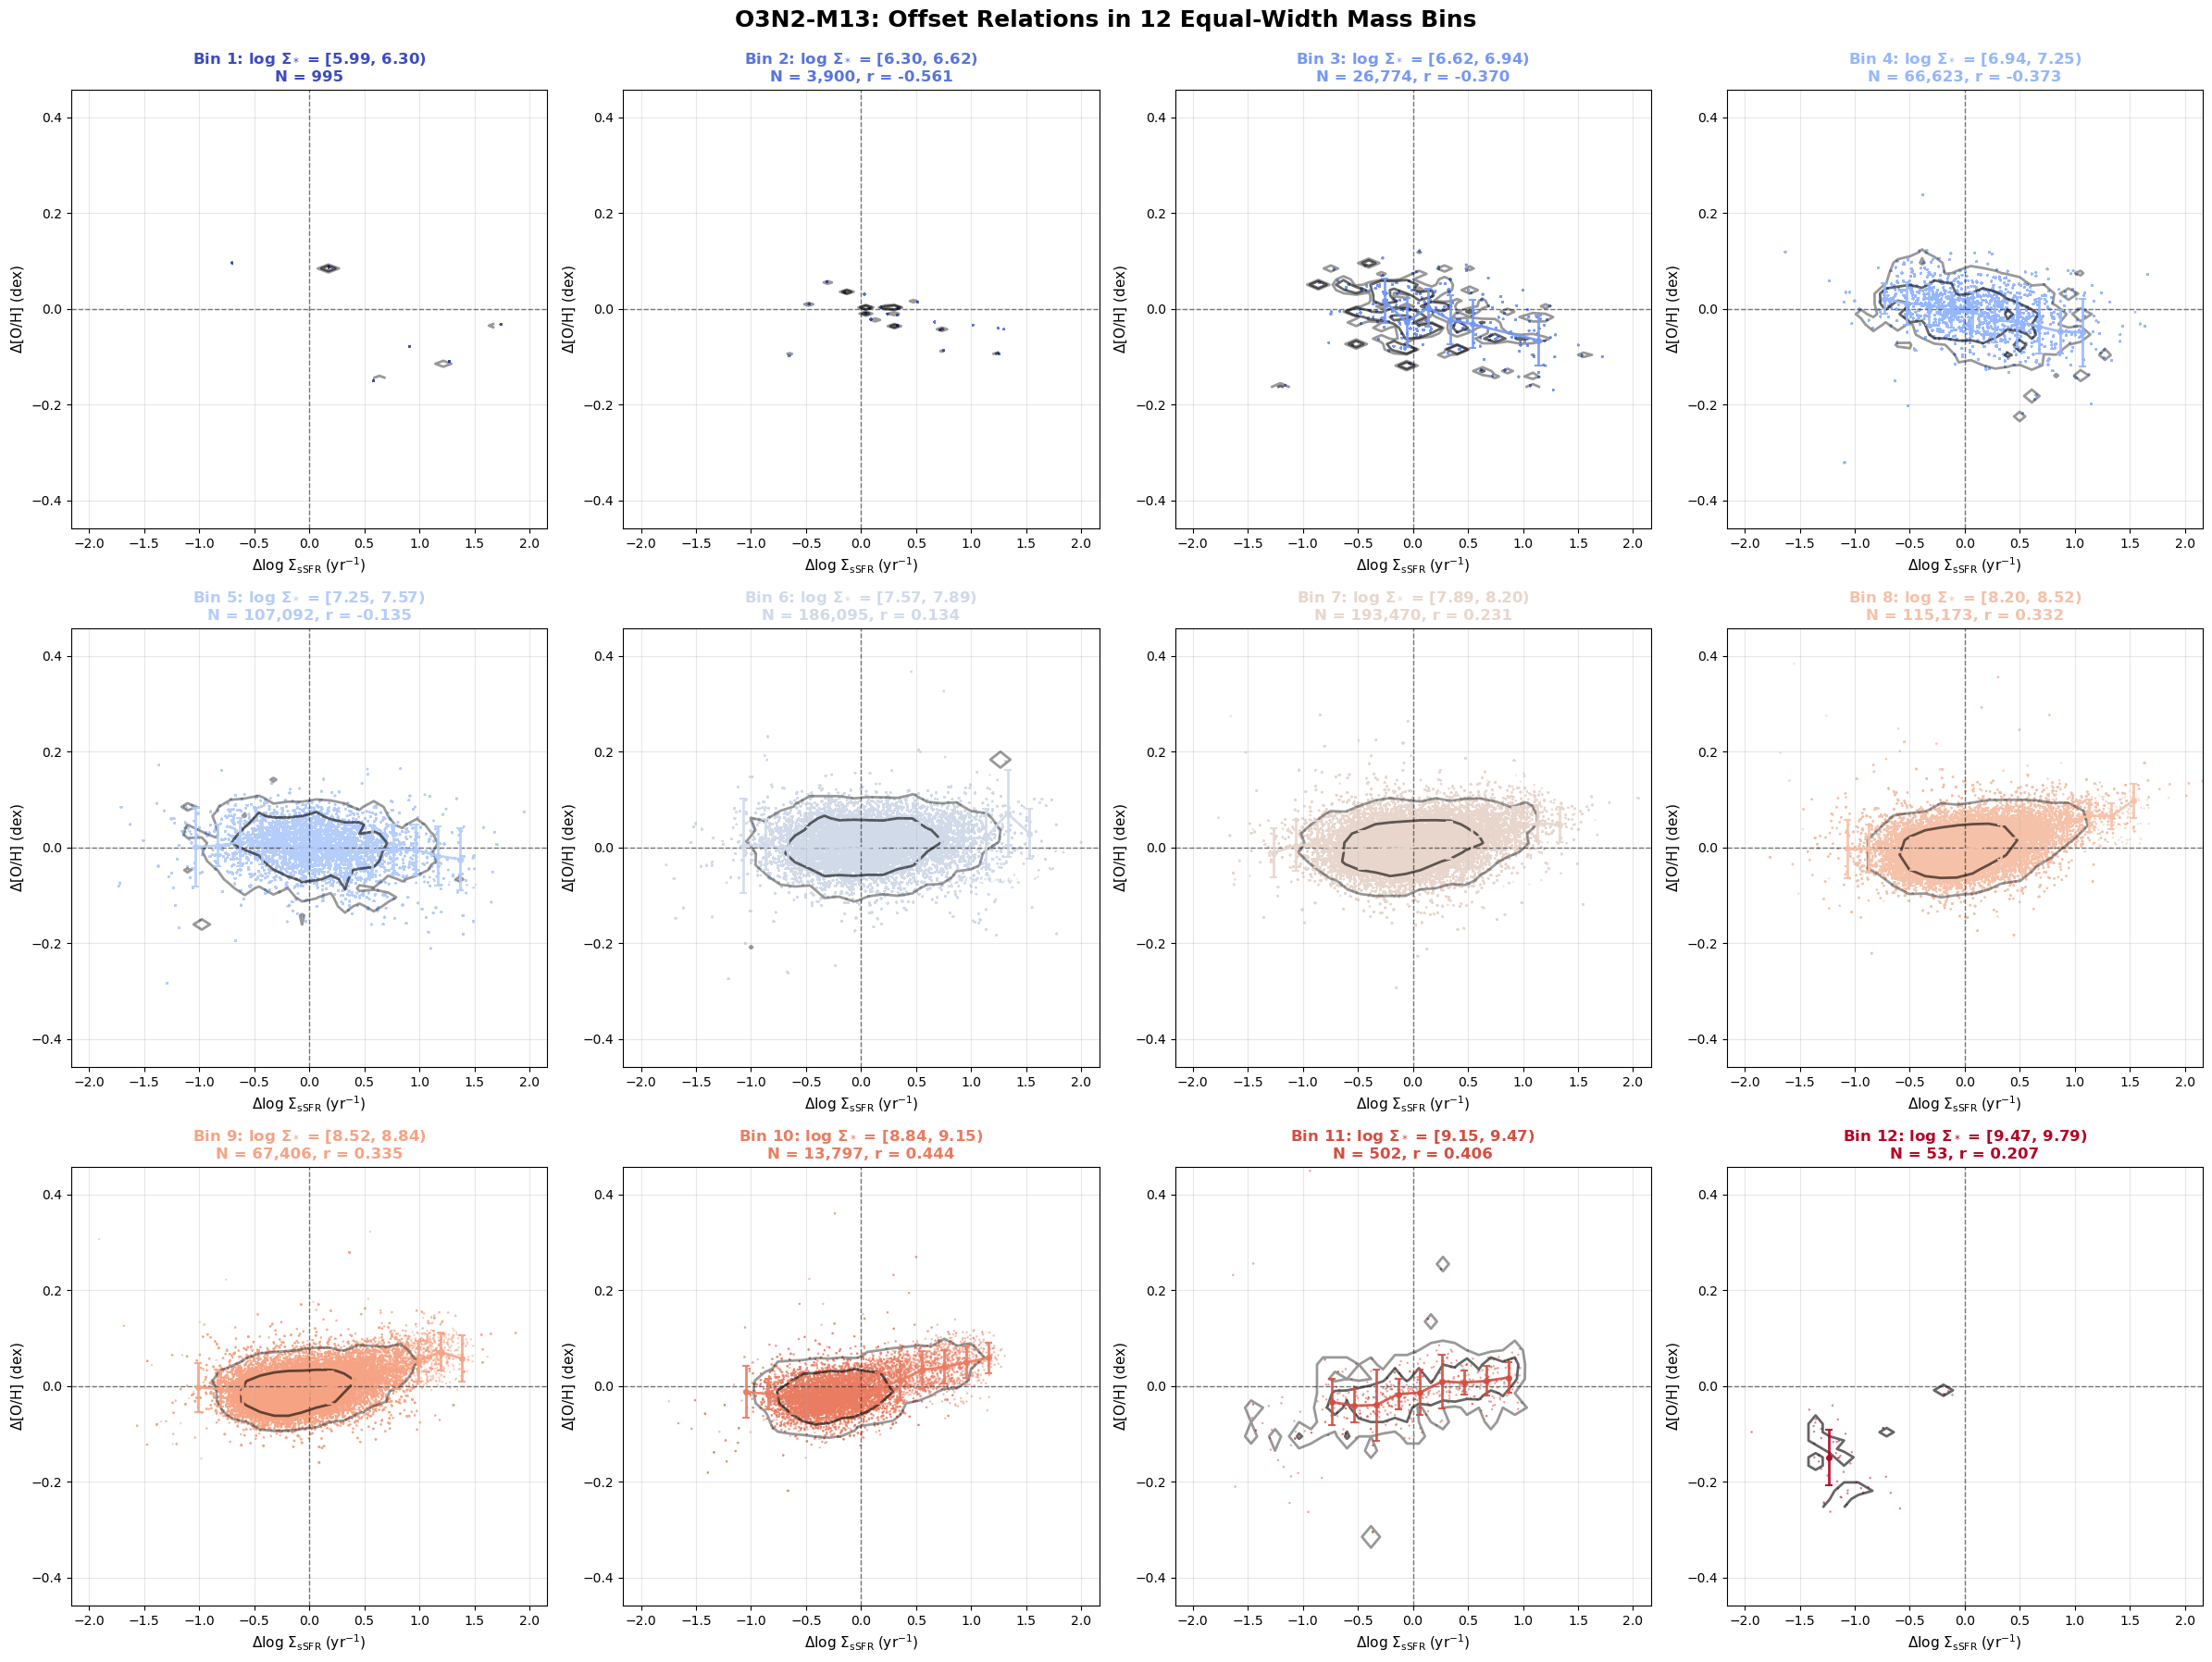


12 mass bin offset plots complete!


In [6]:
# ------------------------------------------------------------------
# O3N2-M13: Offset relation in 12 mass bins (3x4 subplots)
# Each subplot shows one mass bin colored by coolwarm colormap
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.cm as cm

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

print(f"Creating mass-binned offset plots for {len(included_galaxies)} galaxies...")
print(f"Included galaxies: {included_galaxies}")

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def load_maps_o3n2_m13(gal):
    """Load maps for O3N2-M13 metallicity indicator."""
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_map = h_gas['O_H_O3N2_M13_HII'].data
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    
    return sigM, sigSFR, oh_map, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Collect data from all galaxies with mass information
# ------------------------------------------------------------------
all_delta_ssfr = []
all_delta_oh = []
all_sigmaM = []

for gal in included_galaxies:
    try:
        print(f"Loading {gal}...")
        sigM, sigSFR, oh_map, wcs_full, gas_header = load_maps_o3n2_m13(gal)

        # Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
        sigsSFR = sigSFR - sigM

        # Valid pixels across maps
        valid_ssfr = np.isfinite(sigsSFR)
        valid_oh = np.isfinite(oh_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_ssfr & valid_oh & valid_sigM

        # Calculate mean values for offset calculation
        ssfr_mean = np.nanmean(sigsSFR[valid_ssfr])
        oh_mean = np.nanmean(oh_map[valid_oh])
        
        # Create offset maps (difference from mean)
        ssfr_offset = sigsSFR - ssfr_mean
        oh_offset = oh_map - oh_mean

        # Extract valid data points
        delta_ssfr = ssfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]
        sigmaM_vals = sigM[valid_all]
        
        # Add to combined arrays
        all_delta_ssfr.extend(delta_ssfr)
        all_delta_oh.extend(delta_oh)
        all_sigmaM.extend(sigmaM_vals)
        
        print(f"  {gal}: {len(delta_ssfr):,} pixels")
        
    except Exception as e:
        print(f"  Error loading {gal}: {e}")

# Convert to numpy arrays
all_delta_ssfr = np.array(all_delta_ssfr)
all_delta_oh = np.array(all_delta_oh)
all_sigmaM = np.array(all_sigmaM)

print(f"\nTotal combined pixels: {len(all_delta_ssfr):,}")

# ------------------------------------------------------------------
# Create 12 equal-width mass bins
# ------------------------------------------------------------------
n_bins_mass = 12
sigmaM_min = np.nanmin(all_sigmaM)
sigmaM_max = np.nanmax(all_sigmaM)
sigmaM_range = sigmaM_max - sigmaM_min
bin_width_mass = sigmaM_range / n_bins_mass

mass_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_mass + 1)
mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2

# Get coolwarm colormap for mass bins
cmap_mass = cm.get_cmap('coolwarm', n_bins_mass)
mass_bin_colors = [cmap_mass(i) for i in range(n_bins_mass)]

print(f"\nMass bin range: {sigmaM_min:.2f} to {sigmaM_max:.2f}")
print(f"Bin width: {bin_width_mass:.3f}")

# ------------------------------------------------------------------
# Create 3x4 subplot layout (12 mass bins)
# ------------------------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

# Calculate global symmetric axis limits for consistent scales
max_abs_ssfr_global = np.nanmax(np.abs(all_delta_ssfr))
max_abs_oh_global = np.nanmax(np.abs(all_delta_oh))

for i_bin in range(n_bins_mass):
    ax = axes[i_bin]
    
    # Get data for this mass bin
    in_mass_bin = (all_sigmaM >= mass_bin_edges[i_bin]) & (all_sigmaM < mass_bin_edges[i_bin + 1])
    
    delta_ssfr_bin = all_delta_ssfr[in_mass_bin]
    delta_oh_bin = all_delta_oh[in_mass_bin]
    
    n_pixels_bin = len(delta_ssfr_bin)
    bin_color = mass_bin_colors[i_bin]
    
    print(f"\nMass bin {i_bin+1}: [{mass_bin_edges[i_bin]:.2f}, {mass_bin_edges[i_bin+1]:.2f}), N = {n_pixels_bin:,}")
    
    if n_pixels_bin < 10:
        # Not enough data - show empty panel with message
        ax.text(0.5, 0.5, f'Insufficient data\n(N = {n_pixels_bin})', 
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlim(-max_abs_ssfr_global, max_abs_ssfr_global)
        ax.set_ylim(-max_abs_oh_global, max_abs_oh_global)
    else:
        # Plot scatter points with mass bin color
        ax.scatter(delta_ssfr_bin, delta_oh_bin, 
                  c=[bin_color], s=3, alpha=0.5, edgecolors='none', 
                  rasterized=True)

        # Create 2D histogram for contours
        max_abs_ssfr_bin = np.nanmax(np.abs(delta_ssfr_bin))
        max_abs_oh_bin = np.nanmax(np.abs(delta_oh_bin))
        
        H, xedges, yedges = np.histogram2d(delta_ssfr_bin, delta_oh_bin, bins=30,
                                           range=[[-max_abs_ssfr_bin, max_abs_ssfr_bin],
                                                  [-max_abs_oh_bin, max_abs_oh_bin]])
        H = H.T

        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]

        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]

        # Plot contours in black
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            alphas = [0.4, 0.6]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            alphas = [0.6, 0.4]
        else:
            levels_to_plot = [level_68]
            alphas = [0.6]

        if len(levels_to_plot) > 0:
            for level, alpha in zip(levels_to_plot, alphas):
                ax.contour(X, Y, H, levels=[level], colors=['black'],
                          linewidths=[2], alpha=alpha)

        # Calculate median trend with matching color
        bin_centers_x, medians_y, stds_y, counts_y = calculate_binned_stats(
            delta_ssfr_bin, delta_oh_bin, bin_width=0.2, min_pixels=20)

        if len(bin_centers_x) > 0:
            ax.errorbar(bin_centers_x, medians_y, yerr=stds_y, fmt='o-', 
                       color=bin_color, markersize=4, linewidth=2, capsize=3, 
                       capthick=1.5, alpha=0.9, zorder=10)

        # Calculate Pearson correlation
        n_unique = len(np.unique(np.column_stack([delta_ssfr_bin, delta_oh_bin]), axis=0))
        if n_unique >= 20:
            pearson_r, pearson_p = pearsonr(delta_ssfr_bin, delta_oh_bin)
            print(f"  r = {pearson_r:.3f}, p = {pearson_p:.3e}")
        else:
            pearson_r = None
            print(f"  Insufficient unique data (N_unique = {n_unique})")

        # Use global limits for consistency
        ax.set_xlim(-max_abs_ssfr_global, max_abs_ssfr_global)
        ax.set_ylim(-max_abs_oh_global, max_abs_oh_global)

        # Add correlation to title if available
        if pearson_r is not None:
            title = f'Bin {i_bin+1}: log Σ$_*$ = [{mass_bin_edges[i_bin]:.2f}, {mass_bin_edges[i_bin+1]:.2f})\nN = {n_pixels_bin:,}, r = {pearson_r:.3f}'
        else:
            title = f'Bin {i_bin+1}: log Σ$_*$ = [{mass_bin_edges[i_bin]:.2f}, {mass_bin_edges[i_bin+1]:.2f})\nN = {n_pixels_bin:,}'
    
    # Add grid and center lines
    ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3)

    # Labels
    ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{sSFR}} \; (\mathrm{yr}^{-1})$', fontsize=11)
    ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
    
    # Title with mass bin info
    ax.set_title(title, fontsize=12, fontweight='bold', color=bin_color)
    ax.tick_params(labelsize=10)

plt.suptitle('O3N2-M13: Offset Relations in 12 Equal-Width Mass Bins', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig('O3N2_M13_12_Mass_Bins_Offset_Relations.png', dpi=300, bbox_inches='tight')
# plt.savefig('O3N2_M13_12_Mass_Bins_Offset_Relations.pdf', bbox_inches='tight')
plt.show()

print("\n12 mass bin offset plots complete!")


Creating mass-binned offset plots for 13 galaxies...
Included galaxies: ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']
Loading IC3392...
  IC3392: 14,884 pixels
Loading NGC4064...
  NGC4064: 6,949 pixels
Loading NGC4192...
  NGC4192: 145,934 pixels
Loading NGC4293...
  NGC4064: 6,949 pixels
Loading NGC4192...
  NGC4192: 145,934 pixels
Loading NGC4293...
  NGC4293: 4,301 pixels
Loading NGC4298...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4293: 4,301 pixels
Loading NGC4298...
  NGC4298: 156,350 pixels
Loading NGC4330...
  NGC4330: 42,748 pixels
Loading NGC4396...
  NGC4396: 81,742 pixels
Loading NGC4419...
  NGC4419: 7,354 pixels
Loading NGC4457...
  NGC4330: 42,748 pixels
Loading NGC4396...
  NGC4396: 81,742 pixels
Loading NGC4419...
  NGC4419: 7,354 pixels
Loading NGC4457...
  NGC4457: 6,304 pixels
Loading NGC4501...
  NGC4501: 261,001 pixels
Loading NGC4522...
  NGC4457: 6,304 pixel

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_4270/2065641911.py:133: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_mass = cm.get_cmap('coolwarm', n_bins_mass)


  r = 0.279, p = 0.000e+00

Mass bin 7: [7.89, 8.20), N = 192,994
  r = 0.290, p = 0.000e+00

Mass bin 8: [8.20, 8.52), N = 115,055
  r = 0.243, p = 0.000e+00

Mass bin 9: [8.52, 8.84), N = 67,368
  r = 0.290, p = 0.000e+00

Mass bin 8: [8.20, 8.52), N = 115,055
  r = 0.243, p = 0.000e+00

Mass bin 9: [8.52, 8.84), N = 67,368
  r = 0.010, p = 6.854e-03

Mass bin 10: [8.84, 9.15), N = 13,783
  r = -0.238, p = 3.989e-177

Mass bin 11: [9.15, 9.47), N = 500
  r = 0.074, p = 9.713e-02

Mass bin 12: [9.47, 9.79), N = 53
  r = 0.066, p = 6.384e-01
  r = 0.010, p = 6.854e-03

Mass bin 10: [8.84, 9.15), N = 13,783
  r = -0.238, p = 3.989e-177

Mass bin 11: [9.15, 9.47), N = 500
  r = 0.074, p = 9.713e-02

Mass bin 12: [9.47, 9.79), N = 53
  r = 0.066, p = 6.384e-01


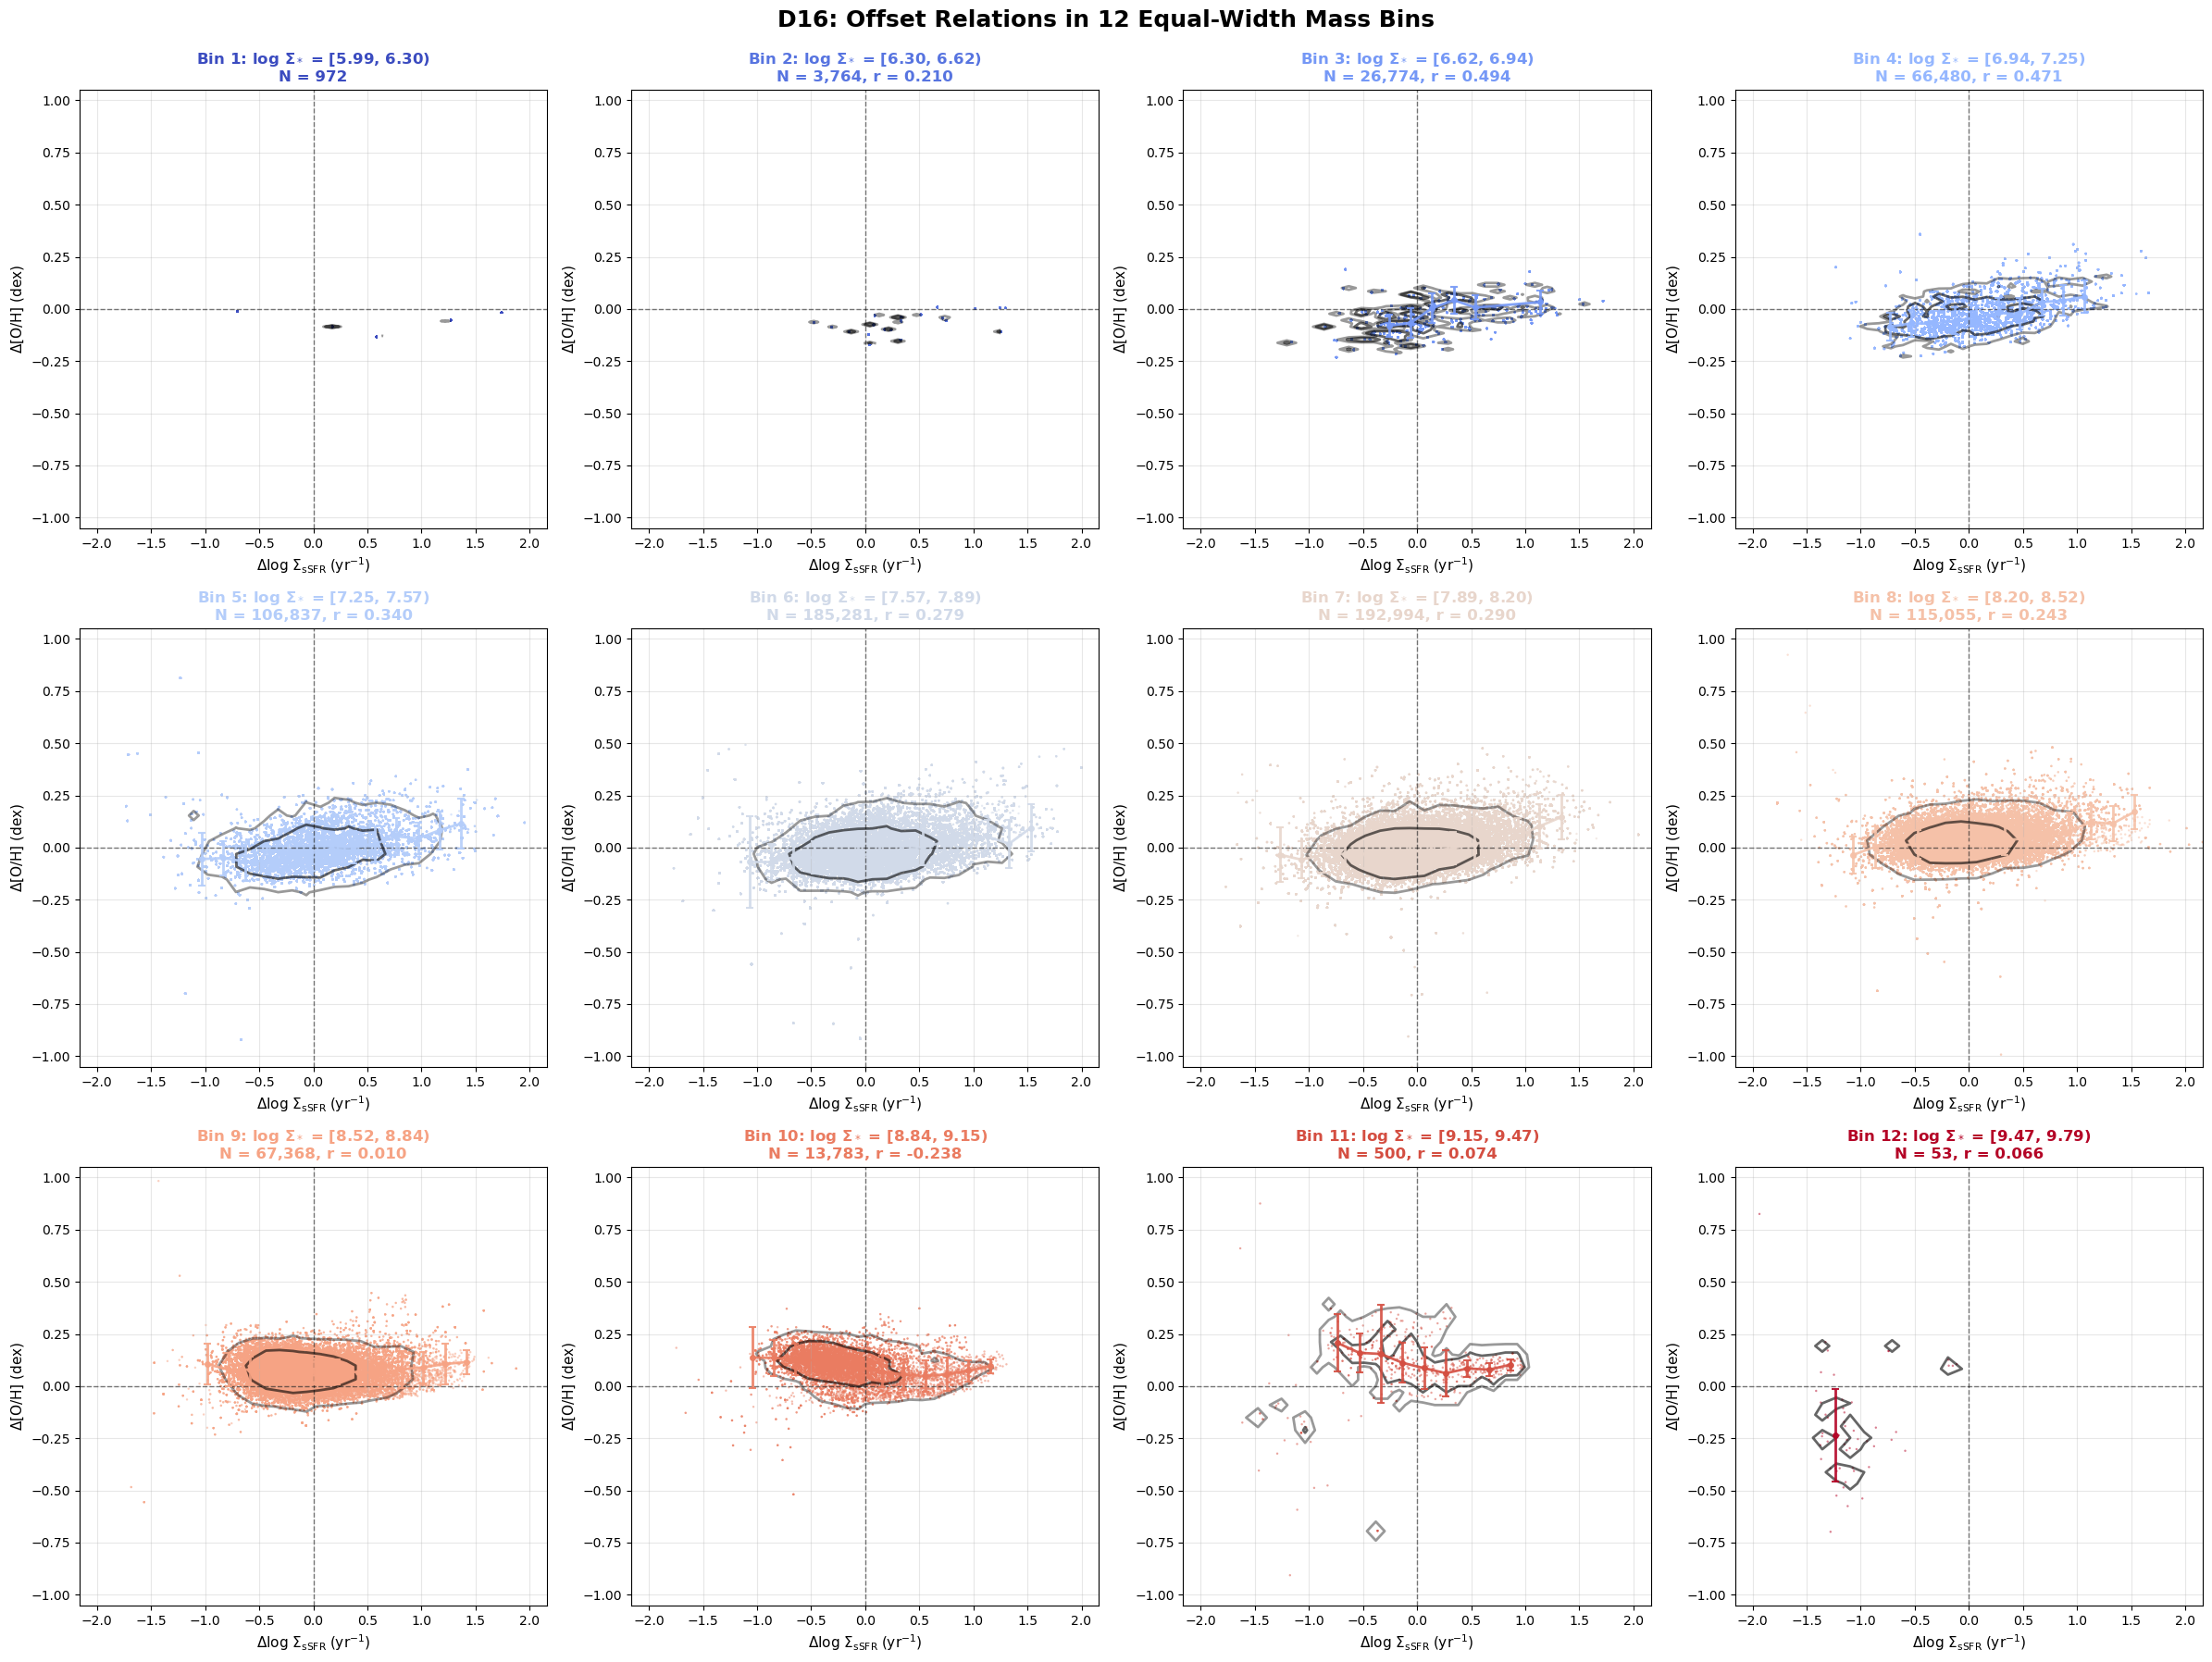


12 mass bin offset plots complete!


In [7]:
# ------------------------------------------------------------------
# D16: Offset relation in 12 mass bins (3x4 subplots)
# Each subplot shows one mass bin colored by coolwarm colormap
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import matplotlib.cm as cm

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

print(f"Creating mass-binned offset plots for {len(included_galaxies)} galaxies...")
print(f"Included galaxies: {included_galaxies}")

# ------------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------------
def load_maps_d16(gal):
    """Load maps for D16 metallicity indicator."""
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_map = h_gas['O_H_D16_HII'].data
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    
    return sigM, sigSFR, oh_map, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Collect data from all galaxies with mass information
# ------------------------------------------------------------------
all_delta_ssfr = []
all_delta_oh = []
all_sigmaM = []

for gal in included_galaxies:
    try:
        print(f"Loading {gal}...")
        sigM, sigSFR, oh_map, wcs_full, gas_header = load_maps_d16(gal)

        # Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
        sigsSFR = sigSFR - sigM

        # Valid pixels across maps
        valid_ssfr = np.isfinite(sigsSFR)
        valid_oh = np.isfinite(oh_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_ssfr & valid_oh & valid_sigM

        # Calculate mean values for offset calculation
        ssfr_mean = np.nanmean(sigsSFR[valid_ssfr])
        oh_mean = np.nanmean(oh_map[valid_oh])
        
        # Create offset maps (difference from mean)
        ssfr_offset = sigsSFR - ssfr_mean
        oh_offset = oh_map - oh_mean

        # Extract valid data points
        delta_ssfr = ssfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]
        sigmaM_vals = sigM[valid_all]
        
        # Add to combined arrays
        all_delta_ssfr.extend(delta_ssfr)
        all_delta_oh.extend(delta_oh)
        all_sigmaM.extend(sigmaM_vals)
        
        print(f"  {gal}: {len(delta_ssfr):,} pixels")
        
    except Exception as e:
        print(f"  Error loading {gal}: {e}")

# Convert to numpy arrays
all_delta_ssfr = np.array(all_delta_ssfr)
all_delta_oh = np.array(all_delta_oh)
all_sigmaM = np.array(all_sigmaM)

print(f"\nTotal combined pixels: {len(all_delta_ssfr):,}")

# ------------------------------------------------------------------
# Create 12 equal-width mass bins
# ------------------------------------------------------------------
n_bins_mass = 12
sigmaM_min = np.nanmin(all_sigmaM)
sigmaM_max = np.nanmax(all_sigmaM)
sigmaM_range = sigmaM_max - sigmaM_min
bin_width_mass = sigmaM_range / n_bins_mass

mass_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins_mass + 1)
mass_bin_centers = (mass_bin_edges[:-1] + mass_bin_edges[1:]) / 2

# Get coolwarm colormap for mass bins
cmap_mass = cm.get_cmap('coolwarm', n_bins_mass)
mass_bin_colors = [cmap_mass(i) for i in range(n_bins_mass)]

print(f"\nMass bin range: {sigmaM_min:.2f} to {sigmaM_max:.2f}")
print(f"Bin width: {bin_width_mass:.3f}")

# ------------------------------------------------------------------
# Create 3x4 subplot layout (12 mass bins)
# ------------------------------------------------------------------
fig, axes = plt.subplots(3, 4, figsize=(24, 18))
axes = axes.flatten()

# Calculate global symmetric axis limits for consistent scales
max_abs_ssfr_global = np.nanmax(np.abs(all_delta_ssfr))
max_abs_oh_global = np.nanmax(np.abs(all_delta_oh))

for i_bin in range(n_bins_mass):
    ax = axes[i_bin]
    
    # Get data for this mass bin
    in_mass_bin = (all_sigmaM >= mass_bin_edges[i_bin]) & (all_sigmaM < mass_bin_edges[i_bin + 1])
    
    delta_ssfr_bin = all_delta_ssfr[in_mass_bin]
    delta_oh_bin = all_delta_oh[in_mass_bin]
    
    n_pixels_bin = len(delta_ssfr_bin)
    bin_color = mass_bin_colors[i_bin]
    
    print(f"\nMass bin {i_bin+1}: [{mass_bin_edges[i_bin]:.2f}, {mass_bin_edges[i_bin+1]:.2f}), N = {n_pixels_bin:,}")
    
    if n_pixels_bin < 10:
        # Not enough data - show empty panel with message
        ax.text(0.5, 0.5, f'Insufficient data\n(N = {n_pixels_bin})', 
               ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_xlim(-max_abs_ssfr_global, max_abs_ssfr_global)
        ax.set_ylim(-max_abs_oh_global, max_abs_oh_global)
    else:
        # Plot scatter points with mass bin color
        ax.scatter(delta_ssfr_bin, delta_oh_bin, 
                  c=[bin_color], s=3, alpha=0.5, edgecolors='none', 
                  rasterized=True)

        # Create 2D histogram for contours
        max_abs_ssfr_bin = np.nanmax(np.abs(delta_ssfr_bin))
        max_abs_oh_bin = np.nanmax(np.abs(delta_oh_bin))
        
        H, xedges, yedges = np.histogram2d(delta_ssfr_bin, delta_oh_bin, bins=30,
                                           range=[[-max_abs_ssfr_bin, max_abs_ssfr_bin],
                                                  [-max_abs_oh_bin, max_abs_oh_bin]])
        H = H.T

        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]

        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]

        # Plot contours in black
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            alphas = [0.4, 0.6]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            alphas = [0.6, 0.4]
        else:
            levels_to_plot = [level_68]
            alphas = [0.6]

        if len(levels_to_plot) > 0:
            for level, alpha in zip(levels_to_plot, alphas):
                ax.contour(X, Y, H, levels=[level], colors=['black'],
                          linewidths=[2], alpha=alpha)

        # Calculate median trend with matching color
        bin_centers_x, medians_y, stds_y, counts_y = calculate_binned_stats(
            delta_ssfr_bin, delta_oh_bin, bin_width=0.2, min_pixels=20)

        if len(bin_centers_x) > 0:
            ax.errorbar(bin_centers_x, medians_y, yerr=stds_y, fmt='o-', 
                       color=bin_color, markersize=4, linewidth=2, capsize=3, 
                       capthick=1.5, alpha=0.9, zorder=10)

        # Calculate Pearson correlation
        n_unique = len(np.unique(np.column_stack([delta_ssfr_bin, delta_oh_bin]), axis=0))
        if n_unique >= 20:
            pearson_r, pearson_p = pearsonr(delta_ssfr_bin, delta_oh_bin)
            print(f"  r = {pearson_r:.3f}, p = {pearson_p:.3e}")
        else:
            pearson_r = None
            print(f"  Insufficient unique data (N_unique = {n_unique})")

        # Use global limits for consistency
        ax.set_xlim(-max_abs_ssfr_global, max_abs_ssfr_global)
        ax.set_ylim(-max_abs_oh_global, max_abs_oh_global)

        # Add correlation to title if available
        if pearson_r is not None:
            title = f'Bin {i_bin+1}: log Σ$_*$ = [{mass_bin_edges[i_bin]:.2f}, {mass_bin_edges[i_bin+1]:.2f})\nN = {n_pixels_bin:,}, r = {pearson_r:.3f}'
        else:
            title = f'Bin {i_bin+1}: log Σ$_*$ = [{mass_bin_edges[i_bin]:.2f}, {mass_bin_edges[i_bin+1]:.2f})\nN = {n_pixels_bin:,}'
    
    # Add grid and center lines
    ax.axhline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    ax.grid(True, alpha=0.3)

    # Labels
    ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{sSFR}} \; (\mathrm{yr}^{-1})$', fontsize=11)
    ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=11)
    
    # Title with mass bin info
    ax.set_title(title, fontsize=12, fontweight='bold', color=bin_color)
    ax.tick_params(labelsize=10)

plt.suptitle('D16: Offset Relations in 12 Equal-Width Mass Bins', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig('D16_12_Mass_Bins_Offset_Relations.png', dpi=300, bbox_inches='tight')
# plt.savefig('D16_12_Mass_Bins_Offset_Relations.pdf', bbox_inches='tight')
plt.show()

print("\n12 mass bin offset plots complete!")


Total galaxies found: 14
Excluded galaxies: {'NGC4383'}
Included galaxies (13): ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']

Color assignments (preserving position for excluded galaxies):

Processing IC3392 (1/13)...
  Pearson: r = 0.187, p = 1.186e-116, N_unique = 2354

Processing NGC4064 (2/13)...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_4270/2848971237.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(galaxies))


  Pearson: r = 0.523, p = 0.000e+00, N_unique = 2869

Processing NGC4192 (3/13)...
  Pearson: r = -0.143, p = 0.000e+00, N_unique = 6908

Processing NGC4293 (4/13)...
  Pearson: r = 0.045, p = 6.005e-04, N_unique = 442

Processing NGC4298 (5/13)...
  Pearson: r = 0.329, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = 0.045, p = 6.005e-04, N_unique = 442

Processing NGC4298 (5/13)...
  Pearson: r = 0.329, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = -0.036, p = 1.669e-13, N_unique = 1760

Processing NGC4396 (7/13)...
  Pearson: r = -0.481, p = 0.000e+00, N_unique = 1743

Processing NGC4419 (8/13)...
  Pearson: r = 0.536, p = 0.000e+00, N_unique = 1297

Processing NGC4457 (9/13)...
  Pearson: r = -0.036, p = 1.669e-13, N_unique = 1760

Processing NGC4396 (7/13)...
  Pearson: r = -0.481, p = 0.000e+00, N_unique = 1743

Processing NGC4419 (8/13)...
  Pearson: r = 0.536, p = 0.000e+00, N_unique = 1297

Processing NGC4457 (9/13)...
 

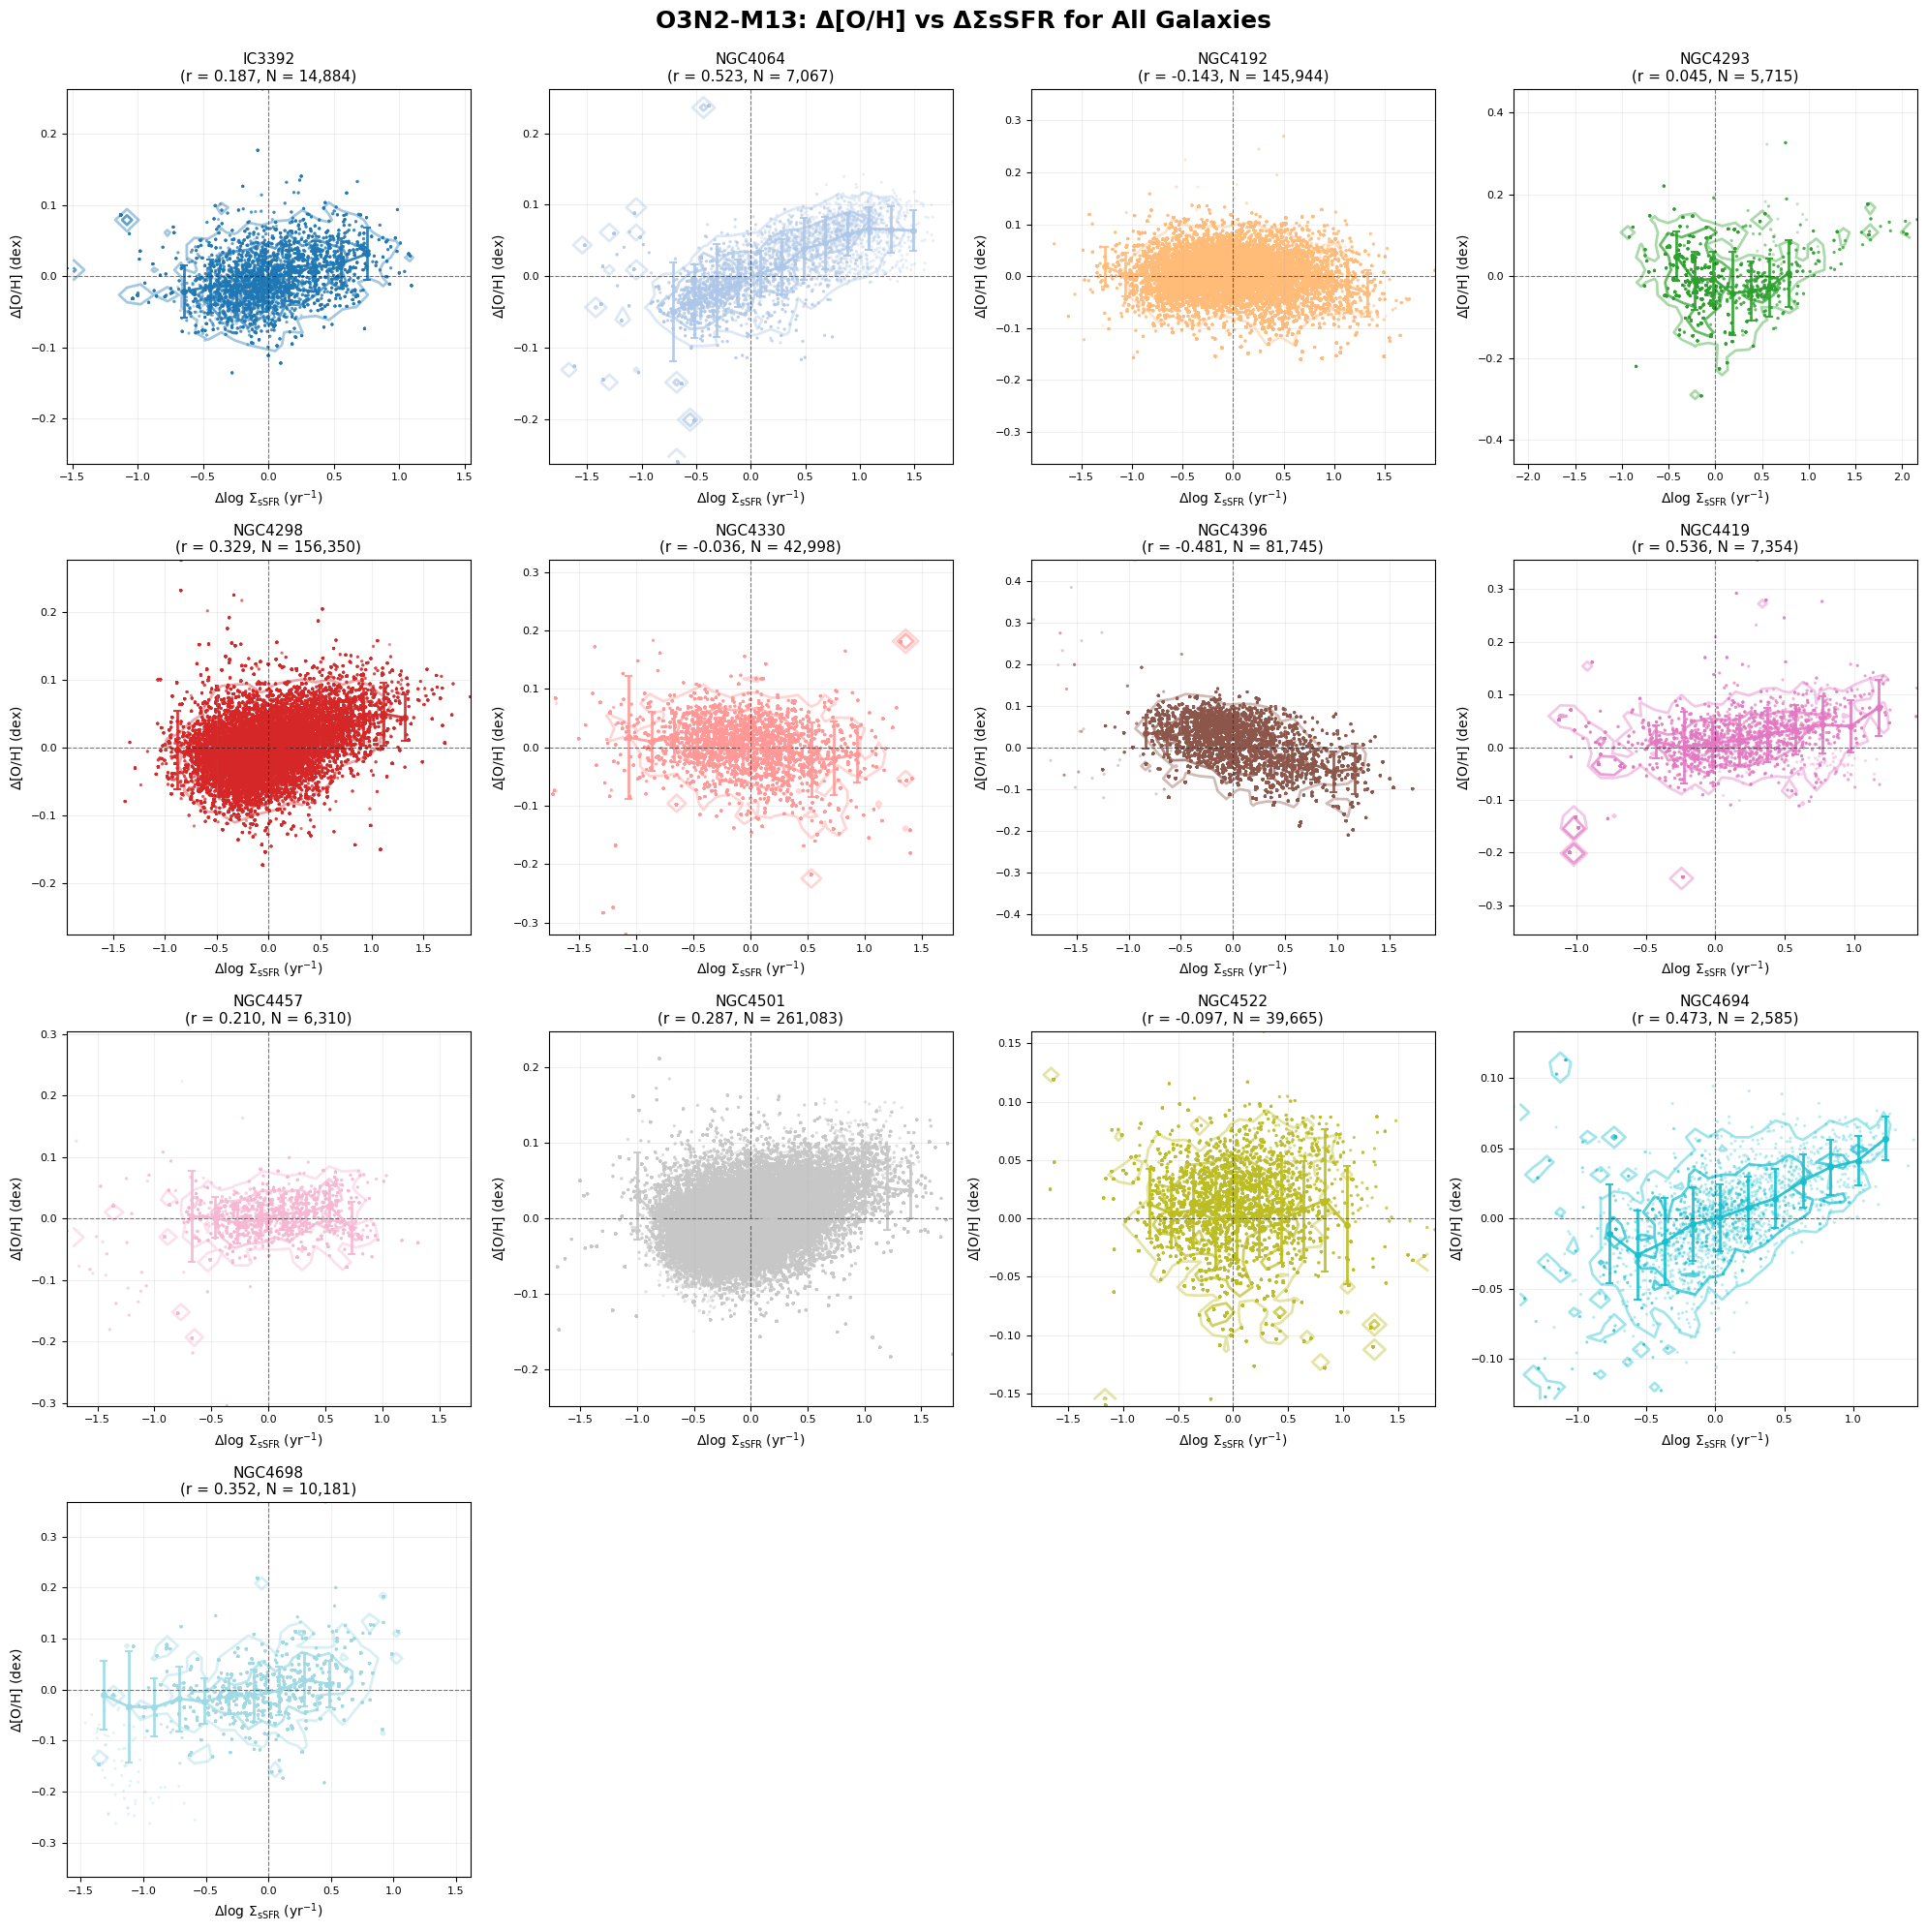


All plots complete!


In [8]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣsSFR for all galaxies (4x4 subplot layout) - O3N2-M13
# Excluding NGC4383
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

print(f"Total galaxies found: {len(galaxies)}")
print(f"Excluded galaxies: {excluded_galaxies}")
print(f"Included galaxies ({len(included_galaxies)}): {included_galaxies}")

# Create color map - preserve color position for all galaxies including excluded ones
import matplotlib.cm as cm
cmap = cm.get_cmap('tab20', len(galaxies))
galaxy_colors = {gal: cmap(i) for i, gal in enumerate(galaxies)}
print(f"\nColor assignments (preserving position for excluded galaxies):")

# ------------------------------------------------------------------
# Helper: read the required maps for O3N2-M13
# ------------------------------------------------------------------
def load_maps_o3n2_m13(gal):
    """Load maps for O3N2-M13 metallicity indicator."""
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_map = h_gas['O_H_O3N2_M13_HII'].data
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Create 4x4 subplot layout
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for idx, gal in enumerate(included_galaxies):
    if idx >= 16:  # Safety check for 4x4 grid
        break
    
    ax = axes[idx]
    
    # Get color for this galaxy
    gal_color = galaxy_colors[gal]
    
    try:
        print(f"\nProcessing {gal} ({idx+1}/{len(included_galaxies)})...")
        
        sigM, sigSFR, oh_o3n2_map, wcs_full, gas_header = load_maps_o3n2_m13(gal)

        # Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
        sigsSFR = sigSFR - sigM

        # Valid pixels across maps
        valid_ssfr = np.isfinite(sigsSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_all = valid_ssfr & valid_oh

        # Calculate mean values for offset calculation
        ssfr_mean = np.nanmean(sigsSFR[valid_ssfr])
        oh_mean = np.nanmean(oh_o3n2_map[valid_oh])
        
        # Create offset maps (difference from mean)
        ssfr_offset = sigsSFR - ssfr_mean
        oh_offset = oh_o3n2_map - oh_mean

        # Extract valid data points
        delta_ssfr = ssfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]

        # Calculate Pearson correlation only if >= 20 unique data points
        n_unique = len(np.unique(np.column_stack([delta_ssfr, delta_oh]), axis=0))
        pearson_r = None
        if n_unique >= 20:
            pearson_r, pearson_p = pearsonr(delta_ssfr, delta_oh)
            print(f"  Pearson: r = {pearson_r:.3f}, p = {pearson_p:.3e}, N_unique = {n_unique}")
        else:
            print(f"  Insufficient unique data (N_unique = {n_unique})")

        # Calculate symmetric axis limits
        max_abs_ssfr = np.nanmax(np.abs(delta_ssfr))
        max_abs_oh = np.nanmax(np.abs(delta_oh))

        # Scatter plot with galaxy-specific color
        ax.scatter(delta_ssfr, delta_oh, c=[gal_color], s=5, alpha=0.3, edgecolors='none', rasterized=True)

        # Create 2D histogram for contours
        H, xedges, yedges = np.histogram2d(delta_ssfr, delta_oh, bins=30,
                                           range=[[-max_abs_ssfr, max_abs_ssfr],
                                                  [-max_abs_oh, max_abs_oh]])
        H = H.T
        
        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]
        
        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.4, 0.7]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.7, 0.4]
        else:
            levels_to_plot = [level_68]
            colors_to_plot = [gal_color]
            alphas = [0.7]
        
        if len(levels_to_plot) > 0:
            for level, color, alpha in zip(levels_to_plot, colors_to_plot, alphas):
                ax.contour(X, Y, H, levels=[level], colors=[color],
                          linewidths=[2], alpha=alpha)
        
        # Calculate median trend
        bin_centers, medians, stds, counts = calculate_binned_stats(
            delta_ssfr, delta_oh, bin_width=0.2, min_pixels=20)
        
        if len(bin_centers) > 0:
            ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                       color=gal_color, markersize=4, linewidth=2, capsize=3, 
                       capthick=1.5, alpha=0.9)
        
        # Set symmetric limits
        ax.set_xlim(-max_abs_ssfr, max_abs_ssfr)
        ax.set_ylim(-max_abs_oh, max_abs_oh)

        # Add grid and center lines
        ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.2)

        # Labels
        ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{sSFR}} \; (\mathrm{yr}^{-1})$', fontsize=10)
        ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=10)
        
        # Title with galaxy name and correlation
        if pearson_r is not None:
            ax.set_title(f'{gal}\n(r = {pearson_r:.3f}, N = {len(delta_ssfr):,})', fontsize=11)
        else:
            ax.set_title(f'{gal}\n(N = {len(delta_ssfr):,})', fontsize=11)
        
        ax.tick_params(labelsize=8)
        
    except Exception as e:
        print(f"  Error processing {gal}: {e}")
        ax.text(0.5, 0.5, f'{gal}\nError', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='red')
        ax.set_xticks([])
        ax.set_yticks([])

# Hide any unused subplots
for idx in range(len(included_galaxies), 16):
    axes[idx].axis('off')

plt.suptitle('O3N2-M13: Δ[O/H] vs ΔΣsSFR for All Galaxies', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig('All_Galaxies_O3N2_M13_Delta_OH_vs_Delta_SigmasSFR_4x4.png', dpi=300, bbox_inches='tight')
# plt.savefig('All_Galaxies_O3N2_M13_Delta_OH_vs_Delta_SigmasSFR_4x4.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("All plots complete!")
print("="*60)


Total galaxies found: 14
Excluded galaxies: {'NGC4383'}
Included galaxies (13): ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']

Color assignments (preserving position for excluded galaxies):

Processing IC3392 (1/13)...

Processing IC3392 (1/13)...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_4270/947643432.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(galaxies))


  Pearson: r = -0.353, p = 0.000e+00, N_unique = 2354

Processing NGC4064 (2/13)...
  Pearson: r = -0.024, p = 4.538e-02, N_unique = 2866

Processing NGC4192 (3/13)...
  Pearson: r = 0.481, p = 0.000e+00, N_unique = 6907

Processing NGC4293 (4/13)...
  Pearson: r = 0.481, p = 0.000e+00, N_unique = 6907

Processing NGC4293 (4/13)...
  Pearson: r = 0.112, p = 1.836e-13, N_unique = 382

Processing NGC4298 (5/13)...
  Pearson: r = 0.150, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = 0.112, p = 1.836e-13, N_unique = 382

Processing NGC4298 (5/13)...
  Pearson: r = 0.150, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = 0.095, p = 1.097e-85, N_unique = 1755
  Pearson: r = 0.095, p = 1.097e-85, N_unique = 1755

Processing NGC4396 (7/13)...
  Pearson: r = 0.384, p = 0.000e+00, N_unique = 1740

Processing NGC4419 (8/13)...
  Pearson: r = 0.425, p = 5.839e-320, N_unique = 1297

Processing NGC4457 (9/13)...
  Pearson: r = 0.458, p = 0.000e+

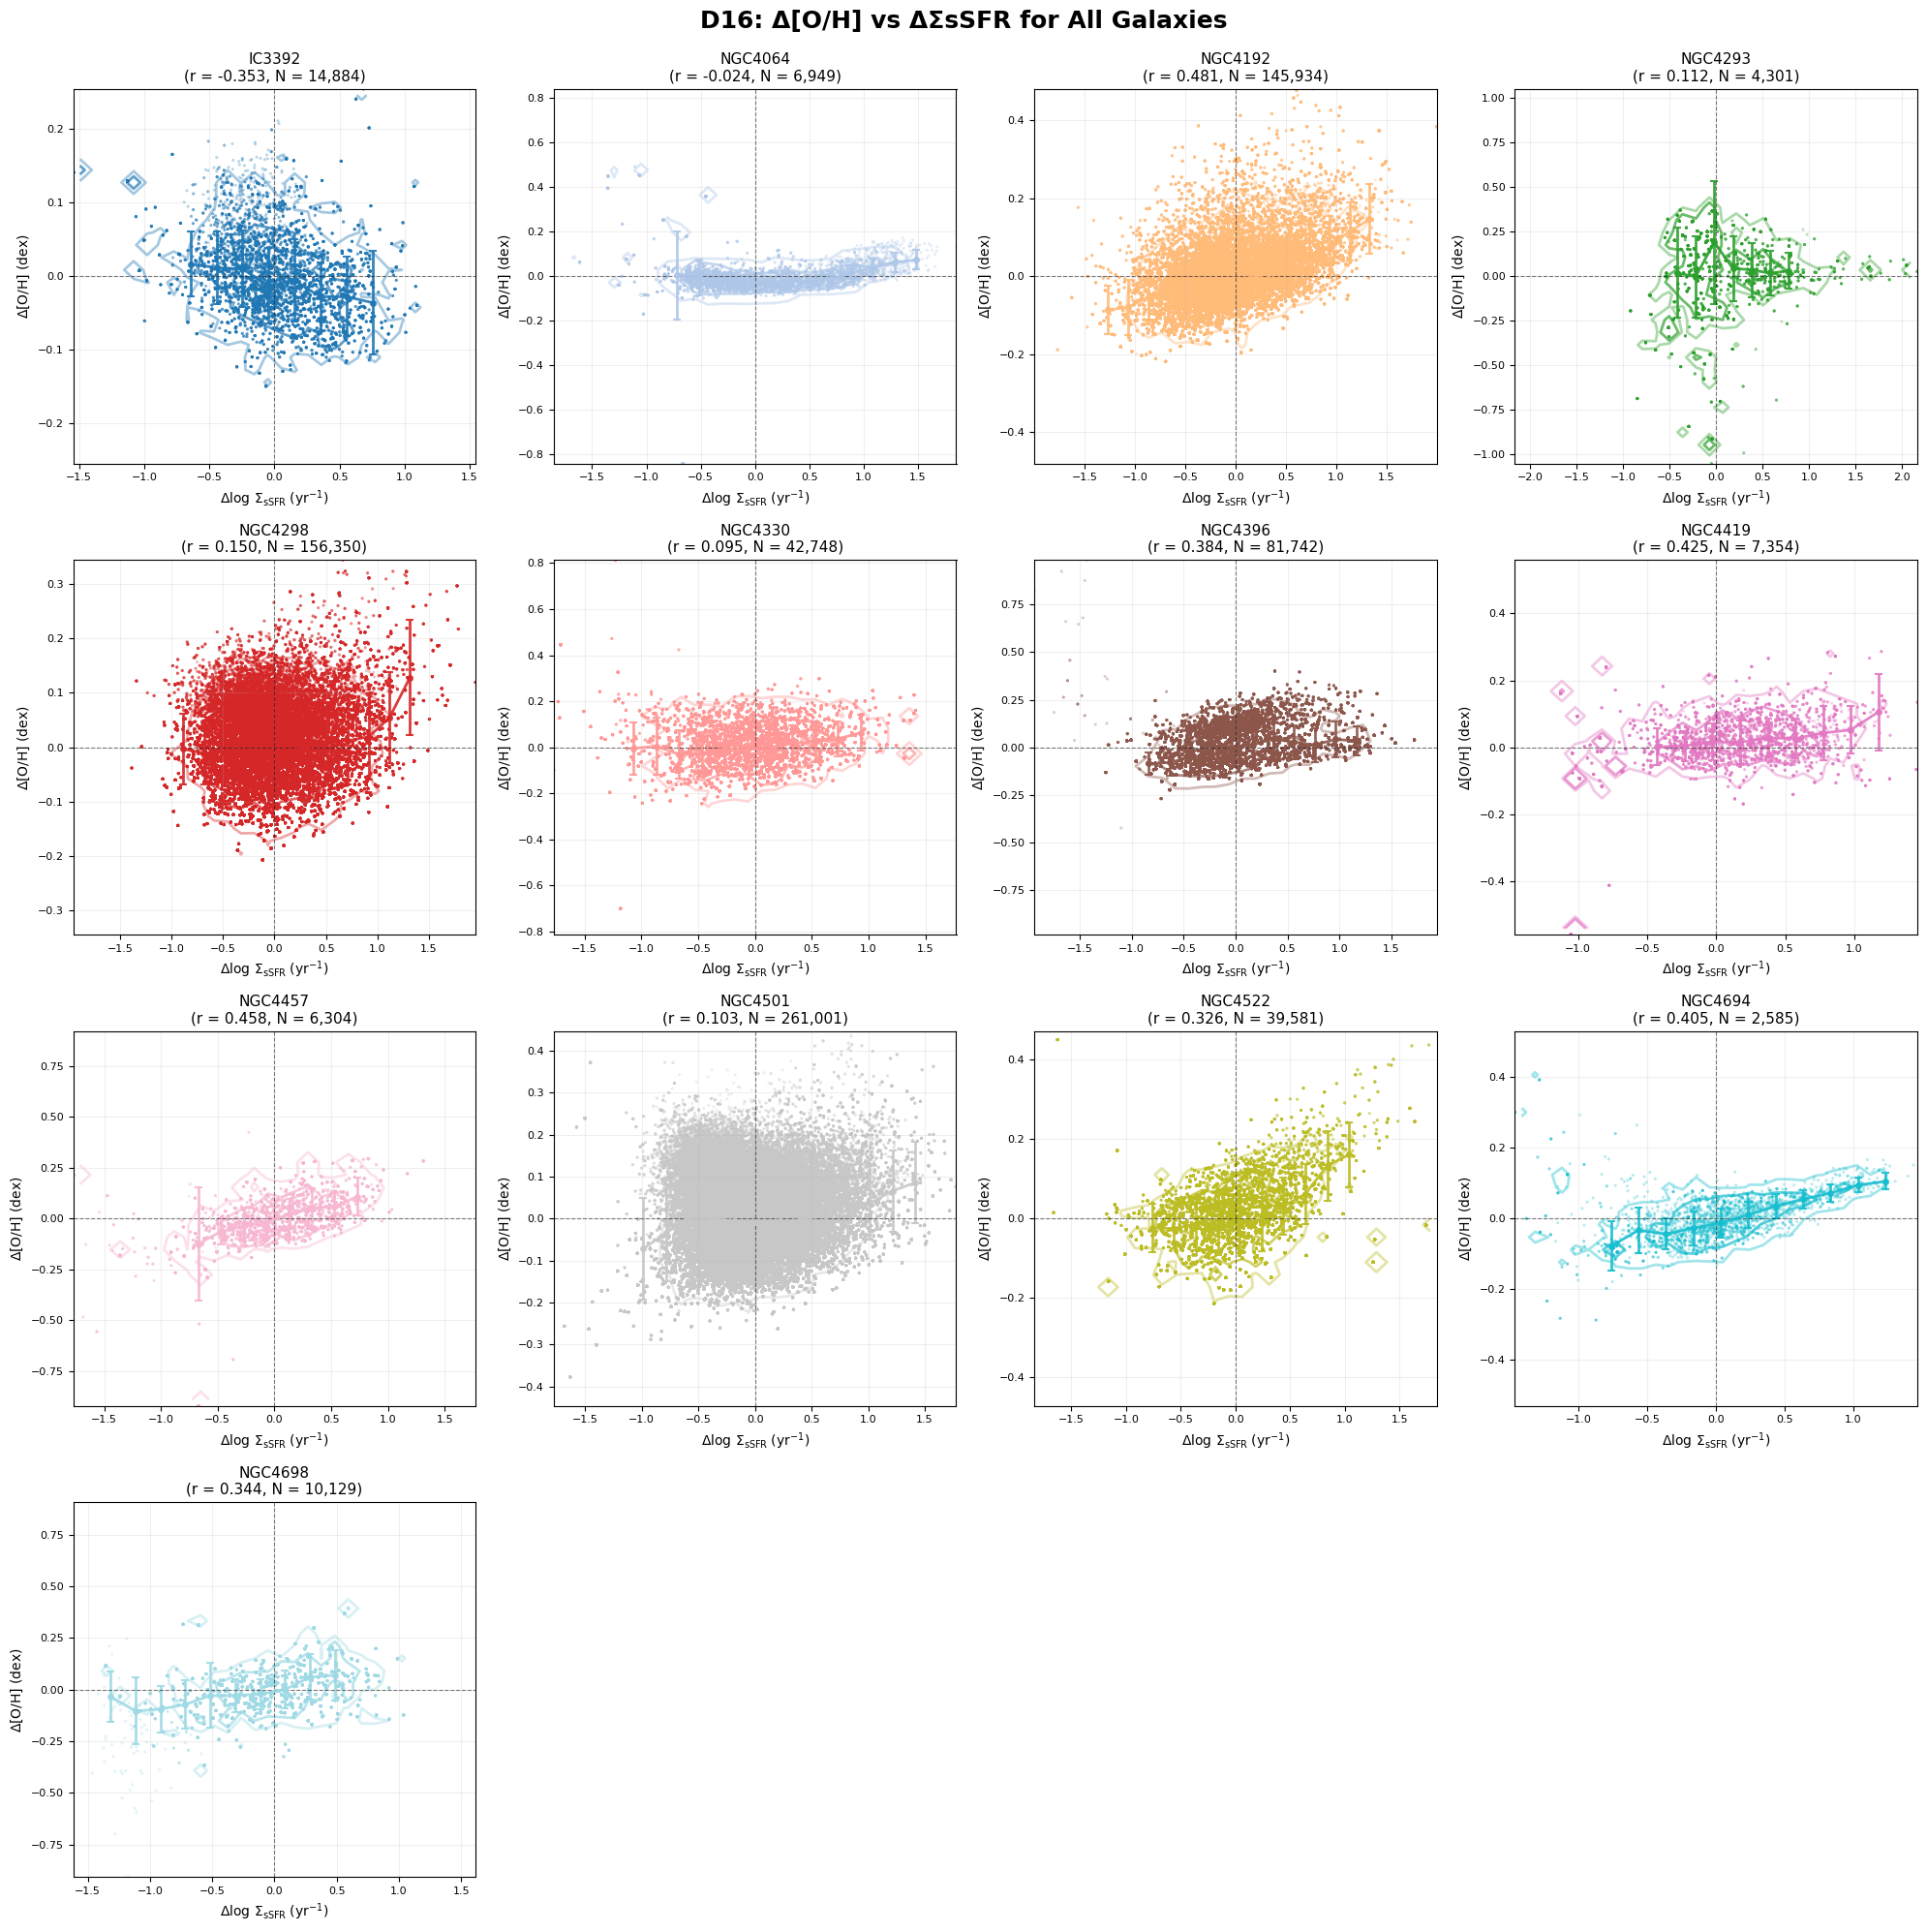


All plots complete!


In [9]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣsSFR for all galaxies (4x4 subplot layout) - D16
# Excluding NGC4383
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

print(f"Total galaxies found: {len(galaxies)}")
print(f"Excluded galaxies: {excluded_galaxies}")
print(f"Included galaxies ({len(included_galaxies)}): {included_galaxies}")

# Create color map - preserve color position for all galaxies including excluded ones
import matplotlib.cm as cm
cmap = cm.get_cmap('tab20', len(galaxies))
galaxy_colors = {gal: cmap(i) for i, gal in enumerate(galaxies)}
print(f"\nColor assignments (preserving position for excluded galaxies):")

# ------------------------------------------------------------------
# Helper: read the required maps for D16
# ------------------------------------------------------------------
def load_maps_d16(gal):
    """Load maps for D16 metallicity indicator."""
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_map = h_gas['O_H_D16_HII'].data
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Create 4x4 subplot layout
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for idx, gal in enumerate(included_galaxies):
    if idx >= 16:  # Safety check for 4x4 grid
        break
    
    ax = axes[idx]
    
    # Get color for this galaxy
    gal_color = galaxy_colors[gal]
    
    try:
        print(f"\nProcessing {gal} ({idx+1}/{len(included_galaxies)})...")
        
        sigM, sigSFR, oh_d16_map, wcs_full, gas_header = load_maps_d16(gal)

        # Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
        sigsSFR = sigSFR - sigM

        # Valid pixels across maps
        valid_ssfr = np.isfinite(sigsSFR)
        valid_oh = np.isfinite(oh_d16_map)
        valid_all = valid_ssfr & valid_oh

        # Calculate mean values for offset calculation
        ssfr_mean = np.nanmean(sigsSFR[valid_ssfr])
        oh_mean = np.nanmean(oh_d16_map[valid_oh])
        
        # Create offset maps (difference from mean)
        ssfr_offset = sigsSFR - ssfr_mean
        oh_offset = oh_d16_map - oh_mean

        # Extract valid data points
        delta_ssfr = ssfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]

        # Calculate Pearson correlation only if >= 20 unique data points
        n_unique = len(np.unique(np.column_stack([delta_ssfr, delta_oh]), axis=0))
        pearson_r = None
        if n_unique >= 20:
            pearson_r, pearson_p = pearsonr(delta_ssfr, delta_oh)
            print(f"  Pearson: r = {pearson_r:.3f}, p = {pearson_p:.3e}, N_unique = {n_unique}")
        else:
            print(f"  Insufficient unique data (N_unique = {n_unique})")

        # Calculate symmetric axis limits
        max_abs_ssfr = np.nanmax(np.abs(delta_ssfr))
        max_abs_oh = np.nanmax(np.abs(delta_oh))

        # Scatter plot with galaxy-specific color
        ax.scatter(delta_ssfr, delta_oh, c=[gal_color], s=5, alpha=0.3, edgecolors='none', rasterized=True)

        # Create 2D histogram for contours
        H, xedges, yedges = np.histogram2d(delta_ssfr, delta_oh, bins=30,
                                           range=[[-max_abs_ssfr, max_abs_ssfr],
                                                  [-max_abs_oh, max_abs_oh]])
        H = H.T
        
        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]
        
        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.4, 0.7]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.7, 0.4]
        else:
            levels_to_plot = [level_68]
            colors_to_plot = [gal_color]
            alphas = [0.7]
        
        if len(levels_to_plot) > 0:
            for level, color, alpha in zip(levels_to_plot, colors_to_plot, alphas):
                ax.contour(X, Y, H, levels=[level], colors=[color],
                          linewidths=[2], alpha=alpha)
        
        # Calculate median trend
        bin_centers, medians, stds, counts = calculate_binned_stats(
            delta_ssfr, delta_oh, bin_width=0.2, min_pixels=20)
        
        if len(bin_centers) > 0:
            ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                       color=gal_color, markersize=4, linewidth=2, capsize=3, 
                       capthick=1.5, alpha=0.9)
        
        # Set symmetric limits
        ax.set_xlim(-max_abs_ssfr, max_abs_ssfr)
        ax.set_ylim(-max_abs_oh, max_abs_oh)

        # Add grid and center lines
        ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.2)

        # Labels
        ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{sSFR}} \; (\mathrm{yr}^{-1})$', fontsize=10)
        ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=10)
        
        # Title with galaxy name and correlation
        if pearson_r is not None:
            ax.set_title(f'{gal}\n(r = {pearson_r:.3f}, N = {len(delta_ssfr):,})', fontsize=11)
        else:
            ax.set_title(f'{gal}\n(N = {len(delta_ssfr):,})', fontsize=11)
        
        ax.tick_params(labelsize=8)
        
    except Exception as e:
        print(f"  Error processing {gal}: {e}")
        ax.text(0.5, 0.5, f'{gal}\nError', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='red')
        ax.set_xticks([])
        ax.set_yticks([])

# Hide any unused subplots
for idx in range(len(included_galaxies), 16):
    axes[idx].axis('off')

plt.suptitle('D16: Δ[O/H] vs ΔΣsSFR for All Galaxies', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig('All_Galaxies_D16_Delta_OH_vs_Delta_SigmasSFR_4x4.png', dpi=300, bbox_inches='tight')
# plt.savefig('All_Galaxies_D16_Delta_OH_vs_Delta_SigmasSFR_4x4.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("All plots complete!")
print("="*60)


Total galaxies found: 14
Excluded galaxies: {'NGC4383'}
Included galaxies (13): ['IC3392', 'NGC4064', 'NGC4192', 'NGC4293', 'NGC4298', 'NGC4330', 'NGC4396', 'NGC4419', 'NGC4457', 'NGC4501', 'NGC4522', 'NGC4694', 'NGC4698']

Color assignments (preserving position for excluded galaxies):

Processing IC3392 (1/13)...
  Pearson: r = -0.361, p = 0.000e+00, N_unique = 2354

Processing NGC4064 (2/13)...


/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_4270/3706749260.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(galaxies))


  Pearson: r = -0.266, p = 1.392e-112, N_unique = 2866

Processing NGC4192 (3/13)...
  Pearson: r = 0.200, p = 0.000e+00, N_unique = 6908

Processing NGC4293 (4/13)...
  Pearson: r = 0.146, p = 8.975e-26, N_unique = 381

Processing NGC4298 (5/13)...
  Pearson: r = -0.243, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = 0.146, p = 8.975e-26, N_unique = 381

Processing NGC4298 (5/13)...
  Pearson: r = -0.243, p = 0.000e+00, N_unique = 9515

Processing NGC4330 (6/13)...
  Pearson: r = -0.100, p = 7.202e-95, N_unique = 1752

Processing NGC4396 (7/13)...
  Pearson: r = 0.296, p = 0.000e+00, N_unique = 1732

Processing NGC4419 (8/13)...
  Pearson: r = -0.100, p = 7.202e-95, N_unique = 1752

Processing NGC4396 (7/13)...
  Pearson: r = 0.296, p = 0.000e+00, N_unique = 1732

Processing NGC4419 (8/13)...
  Pearson: r = 0.368, p = 2.063e-219, N_unique = 1294

Processing NGC4457 (9/13)...
  Pearson: r = 0.470, p = 0.000e+00, N_unique = 826

Processing NGC4501 (10/13)...

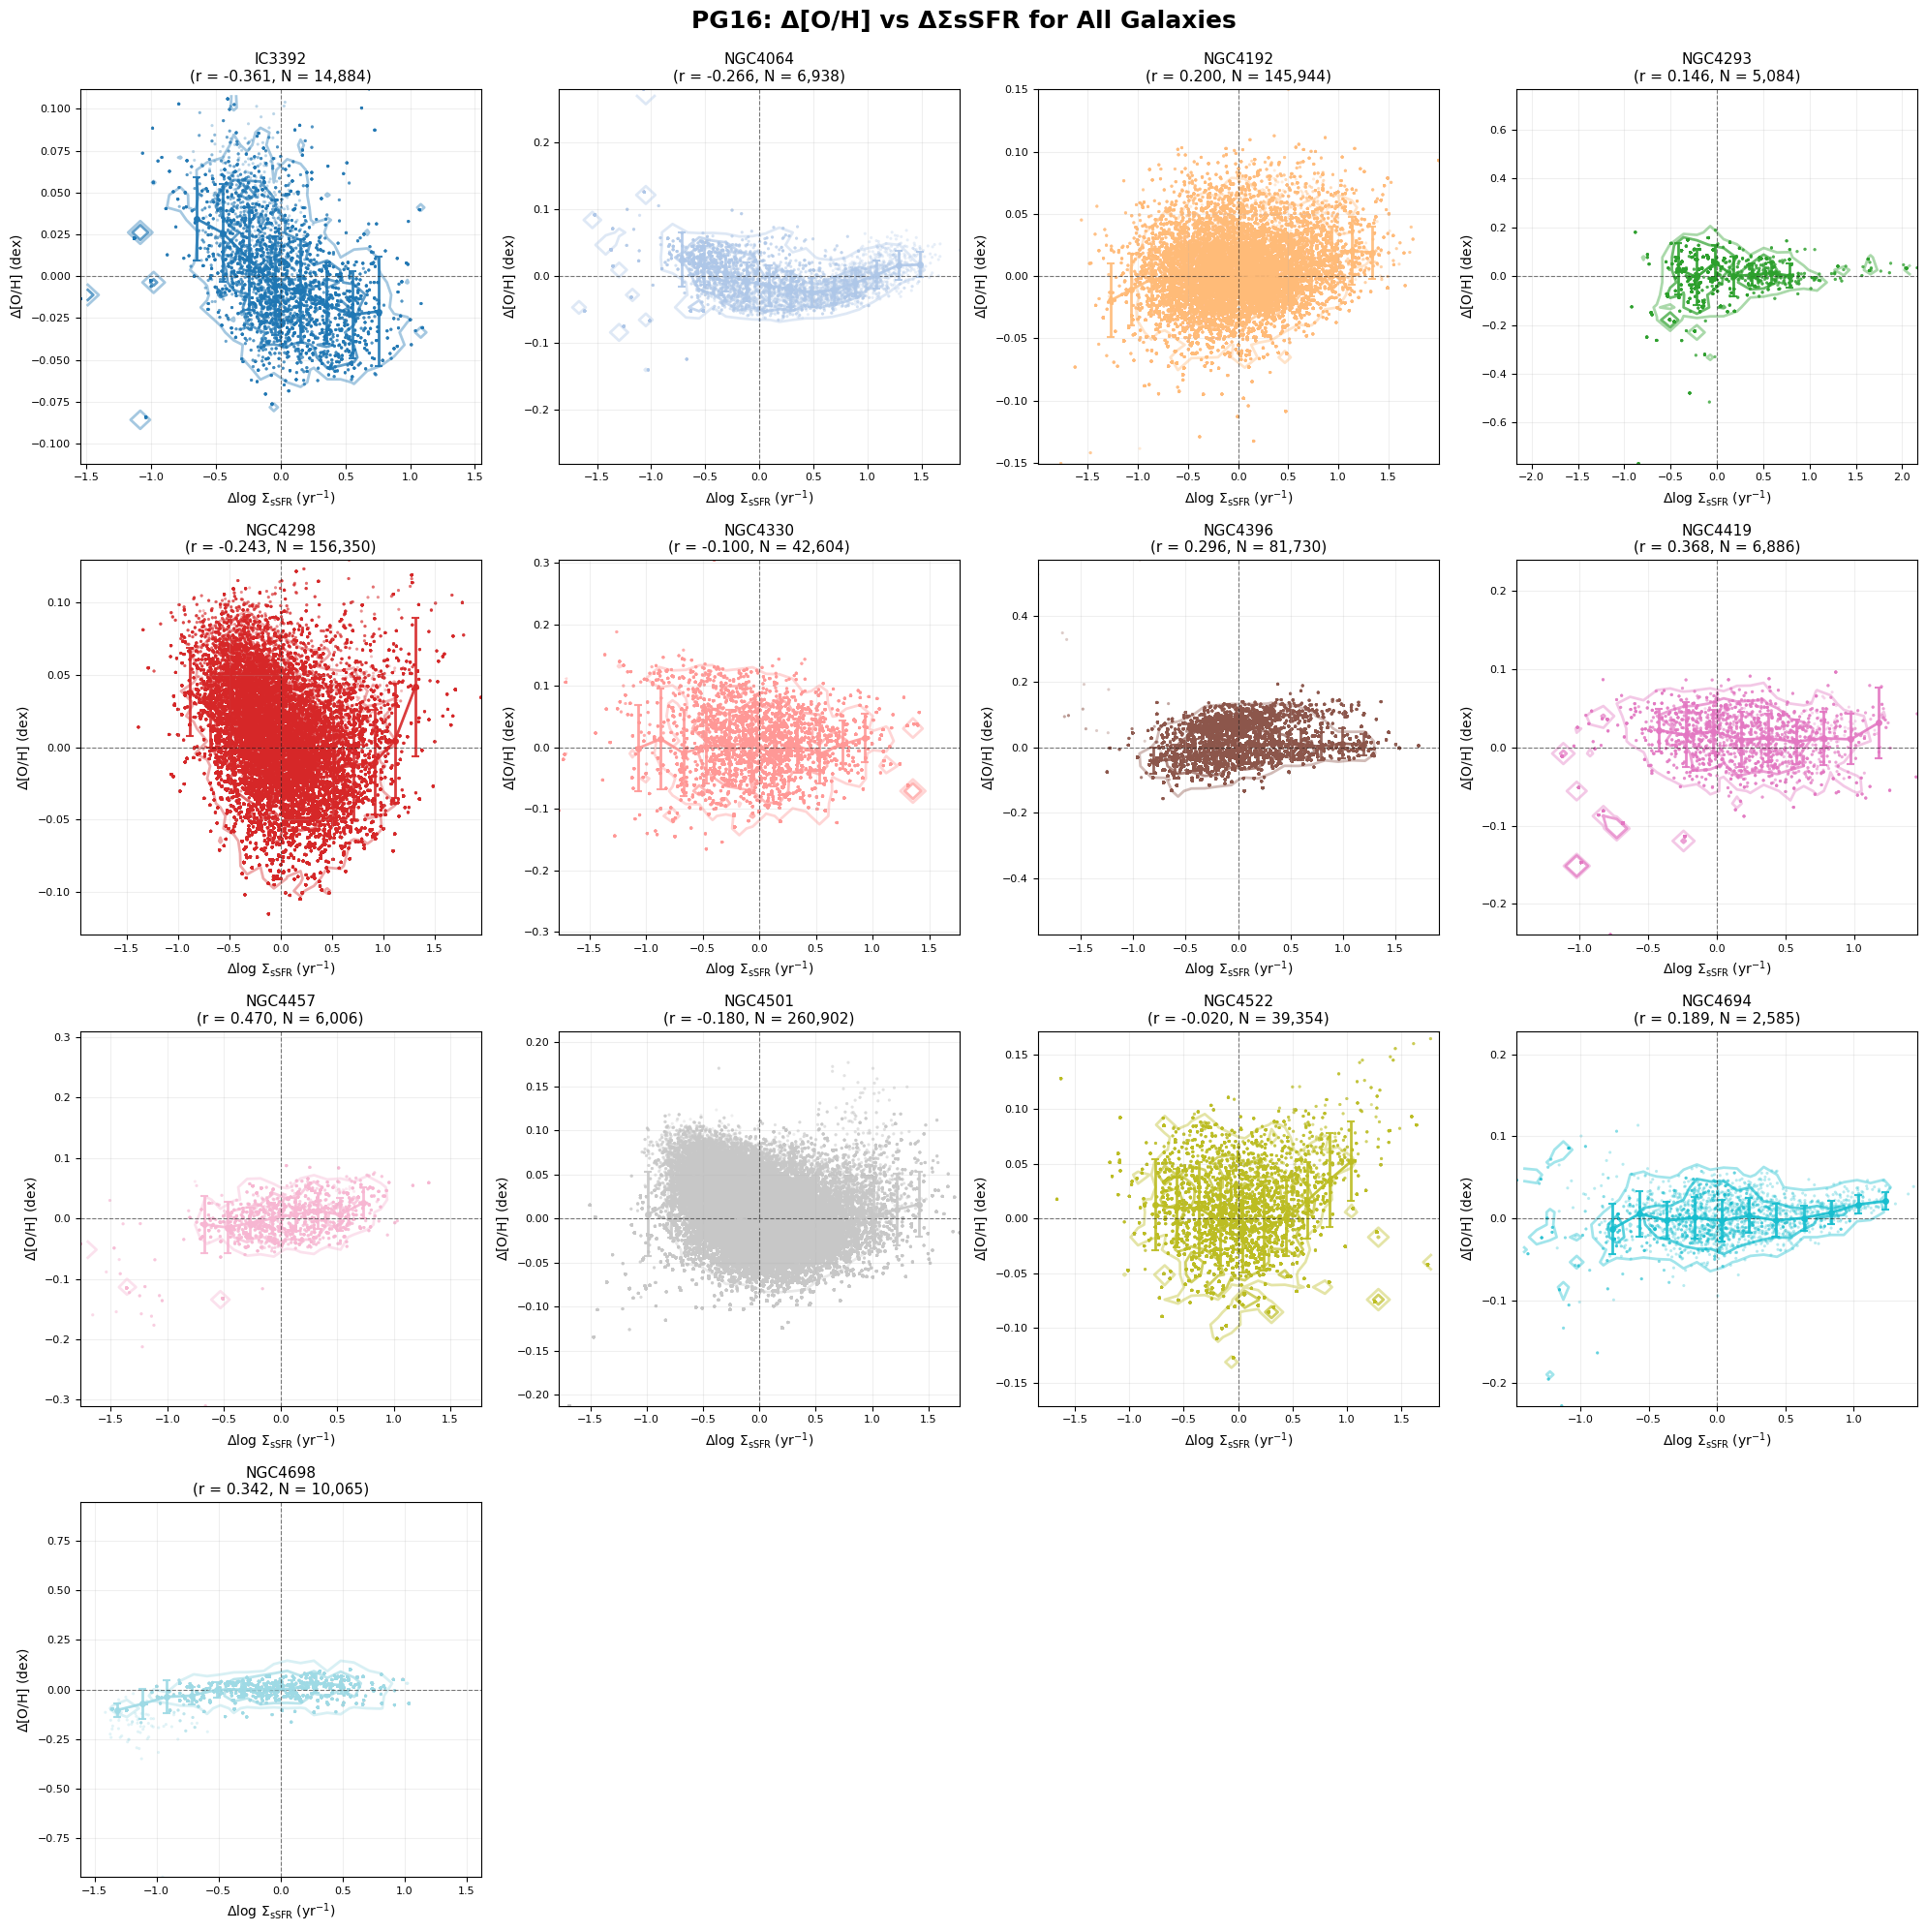


All plots complete!


In [10]:
# ------------------------------------------------------------------
# Plot Δ[O/H] vs ΔΣsSFR for all galaxies (4x4 subplot layout) - PG16
# Excluding NGC4383
# ------------------------------------------------------------------
from pathlib import Path
from astropy.io import fits
from astropy.wcs import WCS
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = [gal for gal in galaxies if gal not in excluded_galaxies]

print(f"Total galaxies found: {len(galaxies)}")
print(f"Excluded galaxies: {excluded_galaxies}")
print(f"Included galaxies ({len(included_galaxies)}): {included_galaxies}")

# Create color map - preserve color position for all galaxies including excluded ones
import matplotlib.cm as cm
cmap = cm.get_cmap('tab20', len(galaxies))
galaxy_colors = {gal: cmap(i) for i, gal in enumerate(galaxies)}
print(f"\nColor assignments (preserving position for excluded galaxies):")

# ------------------------------------------------------------------
# Helper: read the required maps for PG16
# ------------------------------------------------------------------
def load_maps_pg16(gal):
    """Load maps for PG16 metallicity indicator."""
    spatial_path = f'{gal}_SPATIAL_BINNING_maps_extended.fits'
    gas_path = f'{gal}_gas_BIN_maps_extended.fits'

    if not (Path(spatial_path).exists() and Path(gas_path).exists()):
        raise FileNotFoundError(f'Required FITS files for {gal} not found.')

    with fits.open(spatial_path) as h_spatial:
        sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
    with fits.open(gas_path) as h_gas:
        sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_map = h_gas['O_H_PG16_HII'].data
        gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
    return sigM, sigSFR, oh_map, wcs, gas_header

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate binned median and std for scatter data."""
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    bins = np.arange(x_min, x_max + bin_width, bin_width)
    
    bin_centers = []
    medians = []
    stds = []
    counts = []
    
    for i in range(len(bins) - 1):
        mask = (x_data >= bins[i]) & (x_data < bins[i+1])
        y_in_bin = y_data[mask]
        
        # Only include bins with enough unique data points
        if len(np.unique(y_in_bin)) >= min_pixels:
            bin_centers.append((bins[i] + bins[i+1]) / 2)
            medians.append(np.nanmedian(y_in_bin))
            stds.append(np.nanstd(y_in_bin))
            counts.append(len(y_in_bin))
    
    return np.array(bin_centers), np.array(medians), np.array(stds), np.array(counts)

# ------------------------------------------------------------------
# Create 4x4 subplot layout
# ------------------------------------------------------------------
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for idx, gal in enumerate(included_galaxies):
    if idx >= 16:  # Safety check for 4x4 grid
        break
    
    ax = axes[idx]
    
    # Get color for this galaxy
    gal_color = galaxy_colors[gal]
    
    try:
        print(f"\nProcessing {gal} ({idx+1}/{len(included_galaxies)})...")
        
        sigM, sigSFR, oh_pg16_map, wcs_full, gas_header = load_maps_pg16(gal)

        # Calculate sSFR: log(Σ_sSFR) = log(Σ_SFR/Σ_*) = log(Σ_SFR) - log(Σ_*)
        sigsSFR = sigSFR - sigM

        # Valid pixels across maps
        valid_ssfr = np.isfinite(sigsSFR)
        valid_oh = np.isfinite(oh_pg16_map)
        valid_all = valid_ssfr & valid_oh

        # Calculate mean values for offset calculation
        ssfr_mean = np.nanmean(sigsSFR[valid_ssfr])
        oh_mean = np.nanmean(oh_pg16_map[valid_oh])
        
        # Create offset maps (difference from mean)
        ssfr_offset = sigsSFR - ssfr_mean
        oh_offset = oh_pg16_map - oh_mean

        # Extract valid data points
        delta_ssfr = ssfr_offset[valid_all]
        delta_oh = oh_offset[valid_all]

        # Calculate Pearson correlation only if >= 20 unique data points
        n_unique = len(np.unique(np.column_stack([delta_ssfr, delta_oh]), axis=0))
        pearson_r = None
        if n_unique >= 20:
            pearson_r, pearson_p = pearsonr(delta_ssfr, delta_oh)
            print(f"  Pearson: r = {pearson_r:.3f}, p = {pearson_p:.3e}, N_unique = {n_unique}")
        else:
            print(f"  Insufficient unique data (N_unique = {n_unique})")

        # Calculate symmetric axis limits
        max_abs_ssfr = np.nanmax(np.abs(delta_ssfr))
        max_abs_oh = np.nanmax(np.abs(delta_oh))

        # Scatter plot with galaxy-specific color
        ax.scatter(delta_ssfr, delta_oh, c=[gal_color], s=5, alpha=0.3, edgecolors='none', rasterized=True)

        # Create 2D histogram for contours
        H, xedges, yedges = np.histogram2d(delta_ssfr, delta_oh, bins=30,
                                           range=[[-max_abs_ssfr, max_abs_ssfr],
                                                  [-max_abs_oh, max_abs_oh]])
        H = H.T
        
        # Calculate cumulative distribution for contour levels
        H_sorted = np.sort(H.flatten())[::-1]
        H_cumsum = np.cumsum(H_sorted)
        H_cumsum = H_cumsum / H_cumsum[-1]
        
        # Find levels for 68% and 95%
        level_68 = H_sorted[np.argmin(np.abs(H_cumsum - 0.68))]
        level_95 = H_sorted[np.argmin(np.abs(H_cumsum - 0.95))]
        
        # Plot contours
        X, Y = np.meshgrid((xedges[:-1] + xedges[1:]) / 2, (yedges[:-1] + yedges[1:]) / 2)
        if level_95 < level_68:
            levels_to_plot = [level_95, level_68]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.4, 0.7]
        elif level_95 > level_68:
            levels_to_plot = [level_68, level_95]
            colors_to_plot = [gal_color, gal_color]
            alphas = [0.7, 0.4]
        else:
            levels_to_plot = [level_68]
            colors_to_plot = [gal_color]
            alphas = [0.7]
        
        if len(levels_to_plot) > 0:
            for level, color, alpha in zip(levels_to_plot, colors_to_plot, alphas):
                ax.contour(X, Y, H, levels=[level], colors=[color],
                          linewidths=[2], alpha=alpha)
        
        # Calculate median trend
        bin_centers, medians, stds, counts = calculate_binned_stats(
            delta_ssfr, delta_oh, bin_width=0.2, min_pixels=20)
        
        if len(bin_centers) > 0:
            ax.errorbar(bin_centers, medians, yerr=stds, fmt='o-', 
                       color=gal_color, markersize=4, linewidth=2, capsize=3, 
                       capthick=1.5, alpha=0.9)
        
        # Set symmetric limits
        ax.set_xlim(-max_abs_ssfr, max_abs_ssfr)
        ax.set_ylim(-max_abs_oh, max_abs_oh)

        # Add grid and center lines
        ax.axhline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.axvline(0, color='k', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.grid(True, alpha=0.2)

        # Labels
        ax.set_xlabel(r'$\Delta\log\,\Sigma_{\mathrm{sSFR}} \; (\mathrm{yr}^{-1})$', fontsize=10)
        ax.set_ylabel(r'$\Delta$[O/H] (dex)', fontsize=10)
        
        # Title with galaxy name and correlation
        if pearson_r is not None:
            ax.set_title(f'{gal}\n(r = {pearson_r:.3f}, N = {len(delta_ssfr):,})', fontsize=11)
        else:
            ax.set_title(f'{gal}\n(N = {len(delta_ssfr):,})', fontsize=11)
        
        ax.tick_params(labelsize=8)
        
    except Exception as e:
        print(f"  Error processing {gal}: {e}")
        ax.text(0.5, 0.5, f'{gal}\nError', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12, color='red')
        ax.set_xticks([])
        ax.set_yticks([])

# Hide any unused subplots
for idx in range(len(included_galaxies), 16):
    axes[idx].axis('off')

plt.suptitle('PG16: Δ[O/H] vs ΔΣsSFR for All Galaxies', 
             fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.savefig('All_Galaxies_PG16_Delta_OH_vs_Delta_SigmasSFR_4x4.png', dpi=300, bbox_inches='tight')
# plt.savefig('All_Galaxies_PG16_Delta_OH_vs_Delta_SigmasSFR_4x4.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*60)
print("All plots complete!")
print("="*60)
